<a href="https://colab.research.google.com/github/Akshatha-22/Calibration-Confidence/blob/main/model_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/Akshatha-22/Calibration-Confidence.git


Cloning into 'Calibration-Confidence'...
remote: Enumerating objects: 222, done.
remote: Counting objects: 100% (222/222), done.
remote: Compressing objects: 100% (168/168), done.
remote: Total 222 (delta 73), reused 180 (delta 43), pack-reused 0 (from 0)
Receiving objects: 100% (222/222), 7.91 MiB | 8.62 MiB/s, done.
Resolving deltas: 100% (73/73), done.


In [ ]:
# Save the comparison DataFrame to a CSV file
comparison_df.to_csv('model_comparison_results.csv', index=True)
print("Comparison table saved to 'model_comparison_results.csv'")

Comparison table saved to 'model_comparison_results.csv'


In [ ]:
%%writefile experiments/train.py
import argparse
import os
import sys
from typing import Dict, List, Tuple

# Ensure repo root is on sys.path when running this script directly.
# This allows importing from `data` and `models` even if the current working
# directory is not the repo root.
ROOT = os.getcwd() # Changed from os.path.abspath(os.path.join(os.path.dirname(__file__), "."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import numpy as np

try:
    from torch.utils.tensorboard import SummaryWriter

    TENSORBOARD_AVAILABLE = True
except Exception:  # pragma: no cover - optional dependency
    SummaryWriter = None  # type: ignore
    TENSORBOARD_AVAILABLE = False

try:
    import wandb

    WANDB_AVAILABLE = True
except Exception:  # pragma: no cover - optional dependency
    wandb = None  # type: ignore
    WANDB_AVAILABLE = False

from data.preprocessing import FinSenDataset
from models.mlp import build_mlp
from models.deep_mlp import build_deep_mlp
from models.vanilla_rnn import build_vanilla_rnn
from models.lstm import build_lstm
from models.residual_mlp import build_residual_mlp
from calibration.ece import expected_calibration_error, regression_calibration_error


def split_dataset(dataset: FinSenDataset, val_ratio: float = 0.2) -> Tuple[Subset, Subset]:
    """Split dataset into train and validation subsets."""
    n = len(dataset)
    val_size = int(n * val_ratio)
    train_size = n - val_size
    indices = torch.randperm(n).tolist()
    train_idx = indices[:train_size]
    val_idx = indices[train_size:]
    return Subset(dataset, train_idx), Subset(dataset, val_idx)


def _classification_accuracy_counts(
    preds: torch.Tensor, targets: torch.Tensor
) -> Tuple[int, int] | None:
    """Return (correct, total) when predictions/targets define a classification task."""
    if preds.ndim == 0 or targets.ndim == 0:
        return None

    if targets.ndim > 1 and targets.shape[-1] == 1:
        targets = targets.squeeze(-1)
    if preds.ndim > 1 and preds.shape[-1] == 1:
        preds = preds.squeeze(-1)

    if targets.ndim != 1:
        return None

    if preds.ndim > 1 and preds.shape[-1] > 1:
        pred_labels = preds.argmax(dim=-1).reshape(-1)
    elif preds.ndim == 1:
        pred_labels = preds.reshape(-1)
    else:
        return None

    if pred_labels.shape != targets.shape:
        return None

    if targets.dtype in (torch.int8, torch.int16, torch.int32, torch.int64, torch.uint8):
        target_labels = targets
    elif targets.dtype.is_floating_point:
        if not torch.allclose(targets, targets.round(), atol=1e-4, rtol=1e-4):
            return None
        target_labels = targets.round()
    else:
        return None

    target_labels = target_labels.long()
    pred_labels = pred_labels.long()
    total = target_labels.numel()
    correct = int((pred_labels == target_labels).sum().item())
    return correct, total


def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    loss_fn: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
) -> Tuple[float, float, float | None]:
    model.train()
    total_loss = 0.0
    total_grad_norm = 0.0
    num_batches = 0
    correct = 0
    accuracy_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        preds = model(x)
        loss = loss_fn(preds, y).mean() # Apply mean reduction here

        optimizer.zero_grad()
        loss.backward()

        # Aggregate global gradient norm across all parameters for this batch.
        total = 0.0
        for p in model.parameters():
            if p.grad is not None:
                param_norm = p.grad.detach().data.norm(2)
                total += param_norm.item() ** 2
        global_grad_norm = total**0.5

        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

        acc_counts = _classification_accuracy_counts(preds, y)
        if acc_counts is not None:
            correct += acc_counts[0]
            accuracy_samples += acc_counts[1]

    mean_loss = total_loss / num_batches
    mean_grad_norm = total_grad_norm / num_batches

    accuracy = correct / accuracy_samples if accuracy_samples > 0 else None

    return mean_loss, mean_grad_norm, accuracy


def validate_epoch(
    model: nn.Module, loader: DataLoader, loss_fn: nn.Module, device: torch.device
) -> Tuple[float, float | None, torch.Tensor, torch.Tensor, torch.Tensor]:
    model.eval()
    total_loss = 0.0
    num_batches = 0
    correct = 0
    accuracy_samples = 0
    all_preds = []
    all_targets = []
    all_per_example_loss = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            per_example_loss = loss_fn(preds, y) # Get per-example loss without explicit reduction
            loss = per_example_loss.mean() # Apply mean reduction for overall loss

            total_loss += loss.item()
            num_batches += 1

            acc_counts = _classification_accuracy_counts(preds, y)
            if acc_counts is not None:
                correct += acc_counts[0]
                accuracy_samples += acc_counts[1]

            all_preds.append(preds.cpu())
            all_targets.append(y.cpu())
            all_per_example_loss.append(per_example_loss.cpu())

    mean_loss = total_loss / num_batches
    accuracy = correct / accuracy_samples if accuracy_samples > 0 else None

    return (
        mean_loss,
        accuracy,
        torch.cat(all_preds),
        torch.cat(all_targets),
        torch.cat(all_per_example_loss),
    )


def build_model(
    model_type: str,
    seq_len: int,
    num_features: int,
    mlp_hidden_sizes: List[int],
    deep_num_layers: int,
) -> nn.Module:
    if model_type == "mlp":
        return build_mlp(seq_len, num_features, hidden_sizes=mlp_hidden_sizes)
    elif model_type == "deep":
        # Map deep_num_layers to hidden_sizes for build_deep_mlp
        # Assuming a common pattern for hidden layer sizes
        base_deep_hidden_sizes = [256, 128, 64, 32, 16, 8]
        if deep_num_layers > len(base_deep_hidden_sizes):
            raise ValueError(f"deep_num_layers {deep_num_layers} is too large for defined base_deep_hidden_sizes")
        effective_deep_hidden_sizes = base_deep_hidden_sizes[:deep_num_layers]
        return build_deep_mlp(seq_len, num_features, hidden_sizes=effective_deep_hidden_sizes)
    elif model_type == "rnn":
        return build_vanilla_rnn(seq_len, num_features)
    elif model_type == "lstm":
        return build_lstm(seq_len, num_features)
    elif model_type == "residual":
        return build_residual_mlp(seq_len, num_features)
    else:
        raise ValueError(f"Unknown model type: {model_type}")


def train_model(
    data_path: str,
    seq_len: int = 50,
    batch_size: int = 32,
    epochs: int = 20,
    lr: float = 1e-3,
    val_ratio: float = 0.2,
    model_type: str = "mlp",
    checkpoint_path: str = "results/checkpoints/model.pt",
    no_resume: bool = False,
    early_stopping_patience: int = 10,
    log_backend: str = "none",
    log_dir: str = "results/runs",
    wandb_project: str = "calibration-confidence",
    wandb_run_name: str | None = None,
    results_path: str | None = None,
    mlp_hidden_sizes: List[int] = [128, 64],  # New argument for MLP hidden sizes
    deep_num_layers: int = 3,  # New argument for Deep MLP num layers
    ece_n_bins: int = 10, # New argument for ECE bins
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Load data
    dataset = FinSenDataset(data_path=data_path, seq_length=seq_len)
    train_dataset, val_dataset = split_dataset(dataset, val_ratio)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Build model
    model = build_model(model_type, seq_len, dataset.num_features, mlp_hidden_sizes, deep_num_layers).to(device)

    # Loss function and optimizer
    loss_fn = nn.MSELoss(reduction="none") # Initialize with reduction="none"
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Checkpoint and early stopping
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
    best_val_loss = float("inf")
    epochs_without_improvement = 0
    start_epoch = 0

    if os.path.exists(checkpoint_path) and not no_resume:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        # Ensure 'model_type' exists in checkpoint before comparing
        if "model_type" in checkpoint and checkpoint["model_type"] == model_type:
            model.load_state_dict(checkpoint["model_state_dict"])
            optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
            best_val_loss = checkpoint["best_val_loss"]
            start_epoch = checkpoint["epoch"] + 1
            print(f"Resuming from epoch {start_epoch} (best_val_loss={best_val_loss:.4f})")
        else:
            print(
                f"Checkpoint is for model '{checkpoint.get('model_type', 'unknown')}', "
                f"current is '{model_type}'; starting fresh."
            )

    # Logging setup
    writer = None
    if log_backend == "tensorboard" and TENSORBOARD_AVAILABLE:
        log_path = os.path.join(log_dir, wandb_run_name or model_type)
        writer = SummaryWriter(log_path)
        print(f"Logging to TensorBoard at {log_path}")
    elif log_backend == "wandb" and WANDB_AVAILABLE:
        wandb.init(project=wandb_project, name=wandb_run_name or model_type)
        wandb.watch(model, log="all")
        print(f"Logging to Weights & Biases project '{wandb_project}'")

    # Training loop
    train_losses = []
    val_losses = []
    val_accuracies = []
    ece_over_time = []
    train_grad_norms = []

    for epoch in range(start_epoch, epochs):
        train_loss, train_grad_norm, _ = train_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss, val_accuracy, _, _, _ = validate_epoch(model, val_loader, loss_fn, device)

        # Compute ECE on the validation set after each epoch
        # This requires predictions and targets from the validation epoch
        _, _, preds_val, targets_val, per_example_loss_val = validate_epoch(model, val_loader, loss_fn, device)
        ece_val = regression_calibration_error(preds_val, targets_val, n_bins=ece_n_bins) # Removed .item()

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        ece_over_time.append(ece_val)
        train_grad_norms.append(train_grad_norm)

        print(
            f"Epoch {epoch + 1:2d} | "
            f"train_loss={train_loss:.6f} | "
            f"val_loss={val_loss:.6f} | "
            f"ECE={ece_val:.4f} | "
            f"acc={val_accuracy:.3f}"
        )

        if writer:
            writer.add_scalar("Loss/train", train_loss, epoch)
            writer.add_scalar("Loss/val", val_loss, epoch)
            writer.add_scalar("ECE/val", ece_val, epoch)
            if val_accuracy is not None:
                writer.add_scalar("Accuracy/val", val_accuracy, epoch)
            writer.add_scalar("GradNorm/train", train_grad_norm, epoch)

        if log_backend == "wandb" and WANDB_AVAILABLE:
            wandb.log(
                {
                    "train_loss": train_loss,
                    "val_loss": val_loss,
                    "ece": ece_val,
                    "accuracy": val_accuracy,
                    "grad_norm": train_grad_norm,
                }
            )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            torch.save(
                {
                    "epoch": epoch,
                    "model_type": model_type,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_val_loss": best_val_loss,
                },
                checkpoint_path,
            )
            print(f"Saved new best checkpoint to {checkpoint_path}")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= early_stopping_patience:
                print(f"Early stopping: no improvement in val loss for {early_stopping_patience} epochs.")
                break

    if writer:
        writer.close()
    if log_backend == "wandb" and WANDB_AVAILABLE:
        wandb.finish()

    # Collect detailed results on validation set for metrics beyond just loss
    if results_path:
        print(f"Collecting detailed results on validation set to {results_path}")
        _, _, predictions, targets, per_example_loss = validate_epoch(model, val_loader, loss_fn, device)
        np.savez(
            results_path,
            predictions=predictions.cpu().numpy(),
            targets=targets.cpu().numpy(),
            per_example_loss=per_example_loss.cpu().numpy(),
            epochs=np.array(range(start_epoch, epoch + 1)),
            train_loss=np.array(train_losses),
            val_loss=np.array(val_losses),
            ece_over_time=np.array(ece_over_time),
            train_grad_norm=np.array(train_grad_norms),
        )

def main():
    parser = argparse.ArgumentParser(description="Train a windowed model on FinSen data")
    parser.add_argument("--data-path", type=str, default="data/finsen/raw", help="Path to FinSen raw CSV files")
    parser.add_argument("--seq-len", type=int, default=50, help="Sequence length (window size)")
    parser.add_argument("--batch-size", type=int, default=32, help="Training batch size")
    parser.add_argument("--epochs", type=int, default=20, help="Number of training epochs")
    parser.add_argument("--lr", type=float, default=1e-3, help="Learning rate")
    parser.add_argument("--val-ratio", type=float, default=0.2, help="Fraction of data to use for validation")
    parser.add_argument("--model", type=str, default="mlp", choices=["mlp", "deep", "rnn", "lstm", "residual"], help="Model type: 'mlp', 'deep', 'rnn', 'lstm', 'residual'")
    parser.add_argument("--checkpoint-path", type=str, default="results/checkpoints/model.pt", help="Path to save model checkpoints")
    parser.add_argument("--no-resume", action="store_true", help="Do not resume from an existing checkpoint")
    parser.add_argument("--early-stopping-patience", type=int, default=10, help="Early stopping patience in epochs")
    parser.add_argument("--log-backend", type=str, default="none", choices=["none", "tensorboard", "wandb"], help="Logging backend for metrics")
    parser.add_argument("--log-dir", type=str, default="results/runs", help="Base directory for TensorBoard logs")
    parser.add_argument("--wandb-project", type=str, default="calibration-confidence", help="Weights & Biases project name")
    parser.add_argument("--wandb-run-name", type=str, default=None, help="Weights & Biases run name")
    parser.add_argument("--results-path", type=str, default=None, help="Path to save detailed predictions/confidences/ECE")
    parser.add_argument("--mlp-hidden-sizes", type=int, nargs='+', default=[128, 64], help="Hidden layer sizes for MLP model")
    parser.add_argument("--deep-num-layers", type=int, default=3, help="Number of layers for Deep MLP model")
    parser.add_argument("--ece-n-bins", type=int, default=10, help="Number of bins for ECE calculation")

    args = parser.parse_args(sys.argv[1:])

    train_model(
        data_path=args.data_path,
        seq_len=args.seq_len,
        batch_size=args.batch_size,
        epochs=args.epochs,
        lr=args.lr,
        val_ratio=args.val_ratio,
        model_type=args.model,
        checkpoint_path=args.checkpoint_path,
        no_resume=args.no_resume,
        early_stopping_patience=args.early_stopping_patience,
        log_backend=args.log_backend,
        log_dir=args.log_dir,
        wandb_project=args.wandb_project,
        wandb_run_name=args.wandb_run_name,
        results_path=args.results_path,
        mlp_hidden_sizes=args.mlp_hidden_sizes,
        deep_num_layers=args.deep_num_layers,
        ece_n_bins=args.ece_n_bins,
    )

if __name__ == "__main__":
    main()

Overwriting experiments/train.py


In [ ]:
%%bash
cat models/deep_mlp.py

"""Deep MLP model for sliding-window forecasting.

This module defines a deeper fully-connected network that consumes a fixed
window of past observations (seq_length x num_features) and predicts the next
value(s) for the same set of features.

The model flattens the input window into a single vector per batch and passes it
through 4-5 dense layers with optional dropout and activation. This allows it to
learn more complex patterns compared to a shallower MLP.

Example:
    model = DeepMLP(input_size=seq_len * num_features, hidden_sizes=[256, 128, 64, 32], output_size=num_features)

    # In training loop:
    preds = model(x)  # x: (batch, seq_len, num_features)

"""

from __future__ import annotations

from typing import Iterable, Optional

import torch
import torch.nn as nn


class DeepMLP(nn.Module):
    """Deeper feedforward network for sequence-to-one regression.

    The network expects input of shape ``(batch, seq_len, num_features)`` and
    flattens it to ``(batch, seq_len * nu

In [ ]:
%%writefile data/preprocessing/finsen_loader.py
"""
Data loader for FinSen dataset with multiple CSV files.
"""
import os

import numpy as np
import pandas as pd
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from torch.utils.data import Dataset
from typing import Tuple # Added import for Tuple


class FinSenDataset(Dataset):
    def __init__(
        self,
        data_path: str = 'data/finsen/raw',
        seq_length: int = 50,
        text_vectorizer_max_features: int = 128,
    ):
        """Load and merge FinSen CSV files into a sequence dataset.

        If numeric columns are missing, the loader will vectorize the
        available text columns with TF-IDF so the models still receive
        numeric tensors.  It still prefers actual numeric columns when
        they exist (e.g., from the processed folder).
        """
        self.seq_length = seq_length
        self.text_vectorizer_max_features = text_vectorizer_max_features

        self.data = self._load_and_merge_csvs(data_path)
        print(f"Merged data: {self.data.shape[0]} rows, {self.data.shape[1]} columns")

        numeric_df = self.data.select_dtypes(include=[np.number])
        if numeric_df.shape[1] == 0:
            # Try to fall back to processed data if available.
            if os.path.basename(os.path.normpath(data_path)) == 'raw':
                processed_path = os.path.join(os.path.dirname(data_path), 'processed')
                if os.path.isdir(processed_path):
                    print(
                        "No numeric columns found in raw CSVs; "
                        f"trying processed folder: {processed_path}"
                    )
                    self.data = self._load_and_merge_csvs(processed_path)
                    numeric_df = self.data.select_dtypes(include=[np.number])
            if numeric_df.shape[1] == 0:
                numeric_df = self._vectorize_text_columns(self.data)

        if numeric_df.shape[1] == 0:
            raise ValueError(
                "No numeric columns could be derived from the merged dataset. "
                "Ensure the CSV files contain numeric features or text that "
                "can be vectorized."
            )

        self.values = numeric_df.astype(np.float32).values
        self.num_features = self.values.shape[1]
        if numeric_df.shape[1] != self.data.shape[1]:
            dropped = set(self.data.columns) - set(numeric_df.columns)
            print(f"Dropped non-numeric columns: {sorted(dropped)}")

    def _load_and_merge_csvs(self, data_path: str) -> pd.DataFrame:
        """Load all CSV files in a folder and merge them (on 'date' if present)."""
        all_files = [f for f in os.listdir(data_path) if f.endswith('.csv')]

        if len(all_files) == 0:
            raise FileNotFoundError(f"No CSV files found in {data_path}")

        print(f"Found {len(all_files)} CSV files: {all_files}")

        data_frames = []
        for file in all_files:
            file_path = os.path.join(data_path, file)
            df = pd.read_csv(file_path)
            print(f"Loaded {file}: {df.shape[0]} rows, {df.shape[1]} columns")
            data_frames.append(df)

        if len(data_frames) > 1:
            merged_df = data_frames[0]
            for df in data_frames[1:]:
                if 'date' in df.columns:
                    merged_df = pd.merge(merged_df, df, on='date', how='outer')
                else:
                    print(f"Warning: {file} has no 'date' column")
        else:
            merged_df = data_frames[0]

        if 'date' in merged_df.columns:
            merged_df['date'] = pd.to_datetime(merged_df['date'], errors='coerce')
            merged_df = merged_df.sort_values('date').reset_index(drop=True)

        return merged_df

    def _vectorize_text_columns(self, df: pd.DataFrame) -> pd.DataFrame:
        """Convert available text columns into TF-IDF features."""
        text_columns = df.select_dtypes(include=['object', 'string']).columns.tolist()
        if len(text_columns) == 0:
            return pd.DataFrame()

        print(f"Vectorizing text columns: {text_columns}")
        # Concatenate all text columns into a single string for TF-IDF
        # Fill NaN values with empty string to avoid errors during join
        corpus = df[text_columns].fillna('').agg(' '.join, axis=1)

        vectorizer = TfidfVectorizer(max_features=self.text_vectorizer_max_features)
        tfidf_matrix = vectorizer.fit_transform(corpus)

        tfidf_df = pd.DataFrame(
            tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out()
        )
        return tfidf_df

    def __len__(self) -> int:
        return max(0, self.values.shape[0] - self.seq_length)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        if idx >= len(self):
            raise IndexError("Index out of bounds")

        # Input sequence (x) and target (y)
        x = self.values[idx : idx + self.seq_length]
        y = self.values[idx + self.seq_length]

        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

Overwriting data/preprocessing/finsen_loader.py


In [ ]:
import itertools
import numpy as np
import pandas as pd
import os
import subprocess

# Define search space for Deep MLP
deep_num_layers_options = [3, 4, 5, 6]
learning_rates = [0.001, 0.01, 0.0001, 0.0005]

deep_mlp_results = []

for num_layers, lr in itertools.product(deep_num_layers_options, learning_rates):
    print(f"\n--- Training Deep MLP with num_layers={num_layers}, lr={lr} ---")
    results_path = f"results/deep_mlp_tune_l{num_layers}_lr{lr}.npz"
    command_args = [
        "python", "experiments/train.py",
        "--model", "deep",
        "--data-path", "data/finsen/raw",
        "--results-path", results_path,
        "--deep-num-layers", str(num_layers),
        "--lr", str(lr),
        "--no-resume" # Added this argument to prevent loading old checkpoints
    ]

    # Execute the command and capture output
    try:
        result = subprocess.run(command_args, capture_output=True, text=True, check=False)
        print(result.stdout)
        if result.stderr:
            print(f"[STDERR]:\n{result.stderr}")
        if result.returncode != 0:
            print(f"Command failed with exit code {result.returncode}")

        # Check if the results file was actually created before attempting to load
        if os.path.exists(results_path):
            with np.load(results_path, allow_pickle=True) as data:
                val_loss = data['val_loss'][-1]
                ece = data['ece_over_time'][-1]
                deep_mlp_results.append({
                    'num_layers': num_layers,
                    'learning_rate': lr,
                    'val_loss': val_loss,
                    'ECE': ece
                })
        else:
            print(f"Warning: Results file {results_path} not found after training.")
            deep_mlp_results.append({
                'num_layers': num_layers,
                'learning_rate': lr,
                'val_loss': 'File Not Found',
                'ECE': 'File Not Found'
            })
    except Exception as e:
        print(f"Error executing command or loading results: {e}")
        deep_mlp_results.append({
            'num_layers': num_layers,
            'learning_rate': lr,
            'val_loss': 'Error',
            'ECE': 'Error'
        })

deep_mlp_tuning_df = pd.DataFrame(deep_mlp_results)
print("\nDeep MLP Hyperparameter Tuning Results:")
print(deep_mlp_tuning_df)

# Save tuning results
deep_mlp_tuning_df.to_csv('deep_mlp_tuning_results.csv', index=False)
print("Deep MLP tuning results saved to 'deep_mlp_tuning_results.csv'")


--- Training Deep MLP with num_layers=3, lr=0.001 ---
Using device: cuda
Found 3 CSV files: ['FinSen_US_Categorized_Timestamp.csv', 'FinSen_US_Categorized.csv', 'FinSen_US.csv']
Loaded FinSen_US_Categorized_Timestamp.csv: 15534 rows, 4 columns
Loaded FinSen_US_Categorized.csv: 15534 rows, 4 columns
Loaded FinSen_US.csv: 15534 rows, 3 columns
Merged data: 15534 rows, 4 columns
No numeric columns found in raw CSVs; trying processed folder: data/finsen/processed
Found 3 CSV files: ['train.csv', 'val.csv', 'test.csv']
Loaded train.csv: 10873 rows, 5 columns
Loaded val.csv: 2330 rows, 5 columns
Loaded test.csv: 2331 rows, 5 columns
Dropped non-numeric columns: ['Category', 'Content', 'Tag', 'Title']

[STDERR]:
2026-03-19 19:38:14.355761: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773949094.376527   62447 cuda_dnn.cc:8579] Unable to register

In [ ]:
import argparse
import os
import sys
from typing import Dict, List, Tuple

# Ensure repo root is on sys.path when running this script directly.
# This allows importing from `data` and `models` even if the current working
# directory is not the repo root.
ROOT = os.getcwd() # Changed from os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import numpy as np

try:
    from torch.utils.tensorboard import SummaryWriter

    TENSORBOARD_AVAILABLE = True
except Exception:  # pragma: no cover - optional dependency
    SummaryWriter = None  # type: ignore
    TENSORBOARD_AVAILABLE = False

try:
    import wandb

    WANDB_AVAILABLE = True
except Exception:  # pragma: no cover - optional dependency
    wandb = None  # type: ignore
    WANDB_AVAILABLE = False

from data.preprocessing import FinSenDataset
from models.mlp import build_mlp
from models.deep_mlp import build_deep_mlp
from models.vanilla_rnn import build_vanilla_rnn
from models.lstm import build_lstm
from models.residual_mlp import build_residual_mlp
from calibration.ece import expected_calibration_error, regression_calibration_error


def split_dataset(dataset: FinSenDataset, val_ratio: float = 0.2) -> Tuple[Subset, Subset]:
    """Split dataset into train and validation subsets."""
    n = len(dataset)
    val_size = int(n * val_ratio)
    train_size = n - val_size
    indices = torch.randperm(n).tolist()
    train_idx = indices[:train_size]
    val_idx = indices[train_size:]
    return Subset(dataset, train_idx), Subset(dataset, val_idx)


def _classification_accuracy_counts(
    preds: torch.Tensor, targets: torch.Tensor
) -> Tuple[int, int] | None:
    """Return (correct, total) when predictions/targets define a classification task."""
    if preds.ndim == 0 or targets.ndim == 0:
        return None

    if targets.ndim > 1 and targets.shape[-1] == 1:
        targets = targets.squeeze(-1)
    if preds.ndim > 1 and preds.shape[-1] == 1:
        preds = preds.squeeze(-1)

    if targets.ndim != 1:
        return None

    if preds.ndim > 1 and preds.shape[-1] > 1:
        pred_labels = preds.argmax(dim=-1).reshape(-1)
    elif preds.ndim == 1:
        pred_labels = preds.reshape(-1)
    else:
        return None

    if pred_labels.shape != targets.shape:
        return None

    if targets.dtype in (torch.int8, torch.int16, torch.int32, torch.int64, torch.uint8):
        target_labels = targets
    elif targets.dtype.is_floating_point:
        if not torch.allclose(targets, targets.round(), atol=1e-4, rtol=1e-4):
            return None
        target_labels = targets.round()
    else:
        return None

    target_labels = target_labels.long()
    pred_labels = pred_labels.long()
    total = target_labels.numel()
    correct = int((pred_labels == target_labels).sum().item())
    return correct, total


def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    loss_fn: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
) -> Tuple[float, float, float | None]:
    model.train()
    total_loss = 0.0
    total_grad_norm = 0.0
    num_batches = 0
    correct = 0
    accuracy_samples = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        preds = model(x)
        loss = loss_fn(preds, y)

        optimizer.zero_grad()
        loss.backward()

        # Aggregate global gradient norm across all parameters for this batch.
        total = 0.0
        for p in model.parameters():
            if p.grad is not None:
                param_norm = p.grad.detach().data.norm(2)
                total += param_norm.item() ** 2
        global_grad_norm = total**0.5

        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

        acc_counts = _classification_accuracy_counts(preds, y)
        if acc_counts is not None:
            correct += acc_counts[0]
            accuracy_samples += acc_counts[1]

    mean_loss = total_loss / num_batches
    mean_grad_norm = total_grad_norm / num_batches

    accuracy = correct / accuracy_samples if accuracy_samples > 0 else None

    return mean_loss, mean_grad_norm, accuracy


def validate_epoch(
    model: nn.Module, loader: DataLoader, loss_fn: nn.Module, device: torch.device
) -> Tuple[float, float | None, torch.Tensor, torch.Tensor, torch.Tensor]:
    model.eval()
    total_loss = 0.0
    num_batches = 0
    correct = 0
    accuracy_samples = 0
    all_preds = []
    all_targets = []
    all_per_example_loss = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            loss = loss_fn(preds, y)

            total_loss += loss.item()
            num_batches += 1

            acc_counts = _classification_accuracy_counts(preds, y)
            if acc_counts is not None:
                correct += acc_counts[0]
                accuracy_samples += acc_counts[1]

            all_preds.append(preds.cpu())
            all_targets.append(y.cpu())
            all_per_example_loss.append(loss_fn(preds, y, reduction="none").cpu())

    mean_loss = total_loss / num_batches
    accuracy = correct / accuracy_samples if accuracy_samples > 0 else None

    return (
        mean_loss,
        accuracy,
        torch.cat(all_preds),
        torch.cat(all_targets),
        torch.cat(all_per_example_loss),
    )


def build_model(
    model_type: str,
    seq_len: int,
    num_features: int,
    mlp_hidden_sizes: List[int],
    deep_num_layers: int,
) -> nn.Module:
    if model_type == "mlp":
        return build_mlp(seq_len, num_features, hidden_sizes=mlp_hidden_sizes)
    elif model_type == "deep":
        return build_deep_mlp(seq_len, num_features, num_layers=deep_num_layers)
    elif model_type == "rnn":
        return build_vanilla_rnn(seq_len, num_features)
    elif model_type == "lstm":
        return build_lstm(seq_len, num_features)
    elif model_type == "residual":
        return build_residual_mlp(seq_len, num_features)
    else:
        raise ValueError(f"Unknown model type: {model_type}")


def train_model(
    data_path: str,
    seq_len: int = 50,
    batch_size: int = 32,
    epochs: int = 20,
    lr: float = 1e-3,
    val_ratio: float = 0.2,
    model_type: str = "mlp",
    checkpoint_path: str = "results/checkpoints/model.pt",
    no_resume: bool = False,
    early_stopping_patience: int = 10,
    log_backend: str = "none",
    log_dir: str = "results/runs",
    wandb_project: str = "calibration-confidence",
    wandb_run_name: str | None = None,
    results_path: str | None = None,
    mlp_hidden_sizes: List[int] = [128, 64],  # New argument for MLP hidden sizes
    deep_num_layers: int = 3,  # New argument for Deep MLP num layers
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Load data
    dataset = FinSenDataset(data_path=data_path, seq_length=seq_len)
    train_dataset, val_dataset = split_dataset(dataset, val_ratio)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Build model
    model = build_model(model_type, seq_len, dataset.num_features, mlp_hidden_sizes, deep_num_layers).to(device)

    # Loss function and optimizer
    loss_fn = nn.MSELoss(reduction="mean")
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Checkpoint and early stopping
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
    best_val_loss = float("inf")
    epochs_without_improvement = 0
    start_epoch = 0

    if os.path.exists(checkpoint_path) and not no_resume:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        if checkpoint["model_type"] == model_type:
            model.load_state_dict(checkpoint["model_state_dict"])
            optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
            best_val_loss = checkpoint["best_val_loss"]
            start_epoch = checkpoint["epoch"] + 1
            print(f"Resuming from epoch {start_epoch} (best_val_loss={best_val_loss:.4f})")
        else:
            print(
                f"Checkpoint is for model '{checkpoint['model_type']}', "
                f"current is '{model_type}'; starting fresh."
            )

    # Logging setup
    writer = None
    if log_backend == "tensorboard" and TENSORBOARD_AVAILABLE:
        log_path = os.path.join(log_dir, wandb_run_name or model_type)
        writer = SummaryWriter(log_path)
        print(f"Logging to TensorBoard at {log_path}")
    elif log_backend == "wandb" and WANDB_AVAILABLE:
        wandb.init(project=wandb_project, name=wandb_run_name or model_type)
        wandb.watch(model, log="all")
        print(f"Logging to Weights & Biases project '{wandb_project}'")

    # Training loop
    train_losses = []
    val_losses = []
    val_accuracies = []
    ece_over_time = []
    train_grad_norms = []

    for epoch in range(start_epoch, epochs):
        train_loss, train_grad_norm, _ = train_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss, val_accuracy, _, _, _ = validate_epoch(model, val_loader, loss_fn, device)

        # Compute ECE on the validation set after each epoch
        # This requires predictions and targets from the validation epoch
        _, _, preds_val, targets_val, per_example_loss_val = validate_epoch(model, val_loader, loss_fn, device)
        ece_val = regression_calibration_error(preds_val, targets_val, per_example_loss_val).item()

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        ece_over_time.append(ece_val)
        train_grad_norms.append(train_grad_norm)

        print(
            f"Epoch {epoch + 1:2d} | "
            f"train_loss={train_loss:.6f} | "
            f"val_loss={val_loss:.6f} | "
            f"ECE={ece_val:.4f} | "
            f"acc={val_accuracy:.3f}"
        )

        if writer:
            writer.add_scalar("Loss/train", train_loss, epoch)
            writer.add_scalar("Loss/val", val_loss, epoch)
            writer.add_scalar("ECE/val", ece_val, epoch)
            if val_accuracy is not None:
                writer.add_scalar("Accuracy/val", val_accuracy, epoch)
            writer.add_scalar("GradNorm/train", train_grad_norm, epoch)

        if log_backend == "wandb" and WANDB_AVAILABLE:
            wandb.log(
                {
                    "train_loss": train_loss,
                    "val_loss": val_loss,
                    "ece": ece_val,
                    "accuracy": val_accuracy,
                    "grad_norm": train_grad_norm,
                }
            )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            torch.save(
                {
                    "epoch": epoch,
                    "model_type": model_type,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_val_loss": best_val_loss,
                },
                checkpoint_path,
            )
            print(f"Saved new best checkpoint to {checkpoint_path}")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= early_stopping_patience:
                print(f"Early stopping: no improvement in val loss for {early_stopping_patience} epochs.")
                break

    if writer:
        writer.close()
    if log_backend == "wandb" and WANDB_AVAILABLE:
        wandb.finish()

    # Collect detailed results on validation set for metrics beyond just loss
    if results_path:
        print(f"Collecting detailed results on validation set to {results_path}")
        _, _, predictions, targets, per_example_loss = validate_epoch(model, val_loader, loss_fn, device)
        np.savez(
            results_path,
            predictions=predictions.cpu().numpy(),
            targets=targets.cpu().numpy(),
            per_example_loss=per_example_loss.cpu().numpy(),
            epochs=np.array(range(start_epoch, epoch + 1)),
            train_loss=np.array(train_losses),
            val_loss=np.array(val_losses),
            ece_over_time=np.array(ece_over_time),
            train_grad_norm=np.array(train_grad_norms),
        )

def main():
    parser = argparse.ArgumentParser(description="Train a windowed model on FinSen data")
    parser.add_argument("--data-path", type=str, default="data/finsen/raw", help="Path to FinSen raw CSV files")
    parser.add_argument("--seq-len", type=int, default=50, help="Sequence length (window size)")
    parser.add_argument("--batch-size", type=int, default=32, help="Training batch size")
    parser.add_argument("--epochs", type=int, default=20, help="Number of training epochs")
    parser.add_argument("--lr", type=float, default=1e-3, help="Learning rate")
    parser.add_argument("--val-ratio", type=float, default=0.2, help="Fraction of data to use for validation")
    parser.add_argument("--model", type=str, default="mlp", choices=["mlp", "deep", "rnn", "lstm", "residual"], help="Model type: 'mlp', 'deep', 'rnn', 'lstm', 'residual'")
    parser.add_argument("--checkpoint-path", type=str, default="results/checkpoints/model.pt", help="Path to save model checkpoints")
    parser.add_argument("--no-resume", action="store_true", help="Do not resume from an existing checkpoint")
    parser.add_argument("--early-stopping-patience", type=int, default=10, help="Early stopping patience in epochs")
    parser.add_argument("--log-backend", type=str, default="none", choices=["none", "tensorboard", "wandb"], help="Logging backend for metrics")
    parser.add_argument("--log-dir", type=str, default="results/runs", help="Base directory for TensorBoard logs")
    parser.add_argument("--wandb-project", type=str, default="calibration-confidence", help="Weights & Biases project name")
    parser.add_argument("--wandb-run-name", type=str, default=None, help="Weights & Biases run name")
    parser.add_argument("--results-path", type=str, default=None, help="Path to save detailed predictions/confidences/ECE")
    parser.add_argument("--mlp-hidden-sizes", type=int, nargs='+', default=[128, 64], help="Hidden layer sizes for MLP model")
    parser.add_argument("--deep-num-layers", type=int, default=3, help="Number of layers for Deep MLP model")

    args = parser.parse_args(sys.argv[1:])

    train_model(
        data_path=args.data_path,
        seq_len=args.seq_len,
        batch_size=args.batch_size,
        epochs=args.epochs,
        lr=args.lr,
        val_ratio=args.val_ratio,
        model_type=args.model,
        checkpoint_path=args.checkpoint_path,
        no_resume=args.no_resume,
        early_stopping_patience=args.early_stopping_patience,
        log_backend=args.log_backend,
        log_dir=args.log_dir,
        wandb_project=args.wandb_project,
        wandb_run_name=args.wandb_run_name,
        results_path=args.results_path,
        mlp_hidden_sizes=args.mlp_hidden_sizes,
        deep_num_layers=args.deep_num_layers,
    )

if __name__ == "__main__":
    main()

usage: colab_kernel_launcher.py [-h] [--data-path DATA_PATH]
                                [--seq-len SEQ_LEN] [--batch-size BATCH_SIZE]
                                [--epochs EPOCHS] [--lr LR]
                                [--val-ratio VAL_RATIO]
                                [--model {mlp,deep,rnn,lstm,residual}]
                                [--checkpoint-path CHECKPOINT_PATH]
                                [--no-resume]
                                [--early-stopping-patience EARLY_STOPPING_PATIENCE]
                                [--log-backend {none,tensorboard,wandb}]
                                [--log-dir LOG_DIR]
                                [--wandb-project WANDB_PROJECT]
                                [--wandb-run-name WANDB_RUN_NAME]
                                [--results-path RESULTS_PATH]
                                [--mlp-hidden-sizes MLP_HIDDEN_SIZES [MLP_HIDDEN_SIZES ...]]
                                [--deep-num-layers DEEP_NUM_LAYERS

SystemExit: 2

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
%%bash
cat models/mlp.py

"""Simple MLP model for sliding-window forecasting.

This module defines a small fully-connected network that consumes a fixed
window of past observations (seq_length x num_features) and predicts the next
value(s) for the same set of features.

The model flattens the input window into a single vector per batch and passes it
through 2-3 dense layers with optional dropout and activation.

Example:
    model = MLP(input_size=seq_len * num_features, hidden_sizes=[128, 64], output_size=num_features)

    # In training loop:
    preds = model(x)  # x: (batch, seq_len, num_features)

"""

from __future__ import annotations

from typing import Iterable, Optional

import torch
import torch.nn as nn


class MLP(nn.Module):
    """Simple feedforward network for sequence-to-one regression.

    The network expects input of shape ``(batch, seq_len, num_features)`` and
    flattens it to ``(batch, seq_len * num_features)`` before applying linear
    layers.
    """

    def __init__(
        self,
 

In [ ]:
import itertools
import numpy as np
import pandas as pd
import os
import subprocess

# Define search space for MLP
hidden_sizes_options = [[32], [64], [128], [256], [128, 64]]
learning_rates = [0.001, 0.01, 0.0001, 0.0005]

mlp_results = []

for hidden_size_list, lr in itertools.product(hidden_sizes_options, learning_rates):
    # Format hidden_size_list into a space-separated string for the command line argument
    mlp_hidden_sizes_str = ' '.join(map(str, hidden_size_list))
    print(f"\n--- Training MLP with hidden_sizes={hidden_size_list}, lr={lr} ---")
    results_path = f"results/mlp_tune_h{'_'.join(map(str, hidden_size_list))}_lr{lr}.npz"
    command_args = [
        "python", "experiments/train.py",
        "--model", "mlp",
        "--data-path", "data/finsen/raw",
        "--results-path", results_path,
        "--mlp-hidden-sizes", *mlp_hidden_sizes_str.split(),
        "--lr", str(lr),
        "--no-resume" # Added this argument to prevent loading old checkpoints
    ]

    # Execute the command and capture output
    try:
        result = subprocess.run(command_args, capture_output=True, text=True, check=False)
        print(result.stdout)
        if result.stderr:
            print(f"[STDERR]:\n{result.stderr}")
        if result.returncode != 0:
            print(f"Command failed with exit code {result.returncode}")

        # Check if the results file was actually created before attempting to load
        if os.path.exists(results_path):
            with np.load(results_path, allow_pickle=True) as data:
                val_loss = data['val_loss'][-1]
                ece = data['ece_over_time'][-1]
                mlp_results.append({
                    'hidden_sizes': hidden_size_list,
                    'learning_rate': lr,
                    'val_loss': val_loss,
                    'ECE': ece
                })
        else:
            print(f"Warning: Results file {results_path} not found after training.")
            mlp_results.append({
                'hidden_sizes': hidden_size_list,
                'learning_rate': lr,
                'val_loss': 'File Not Found',
                'ECE': 'File Not Found'
            })
    except Exception as e:
        print(f"Error executing command or loading results: {e}")
        mlp_results.append({
            'hidden_sizes': hidden_size_list,
            'learning_rate': lr,
            'val_loss': 'Error',
            'ECE': 'Error'
        })

mlp_tuning_df = pd.DataFrame(mlp_results)
print("\nMLP Hyperparameter Tuning Results:")
print(mlp_tuning_df)

# Save tuning results
mlp_tuning_df.to_csv('mlp_tuning_results.csv', index=False)
print("MLP tuning results saved to 'mlp_tuning_results.csv'")


--- Training MLP with hidden_sizes=[32], lr=0.001 ---
Using device: cuda
Found 3 CSV files: ['FinSen_US_Categorized_Timestamp.csv', 'FinSen_US_Categorized.csv', 'FinSen_US.csv']
Loaded FinSen_US_Categorized_Timestamp.csv: 15534 rows, 4 columns
Loaded FinSen_US_Categorized.csv: 15534 rows, 4 columns
Loaded FinSen_US.csv: 15534 rows, 3 columns
Merged data: 15534 rows, 4 columns
No numeric columns found in raw CSVs; trying processed folder: data/finsen/processed
Found 3 CSV files: ['train.csv', 'val.csv', 'test.csv']
Loaded train.csv: 10873 rows, 5 columns
Loaded val.csv: 2330 rows, 5 columns
Loaded test.csv: 2331 rows, 5 columns
Dropped non-numeric columns: ['Category', 'Content', 'Tag', 'Title']

[STDERR]:
2026-03-19 19:33:24.312873: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773948804.334374   60941 cuda_dnn.cc:8579] Unable to register

In [ ]:
import itertools
import numpy as np
import pandas as pd
import os
import subprocess

# Define search space for Deep MLP
deep_num_layers_options = [3, 4, 5, 6]
learning_rates = [0.001, 0.01, 0.0001, 0.0005]

deep_mlp_results = []

for num_layers, lr in itertools.product(deep_num_layers_options, learning_rates):
    print(f"\n--- Training Deep MLP with num_layers={num_layers}, lr={lr} ---")
    results_path = f"results/deep_mlp_tune_l{num_layers}_lr{lr}.npz"
    command_args = [
        "python", "experiments/train.py",
        "--model", "deep",
        "--data-path", "data/finsen/raw",
        "--results-path", results_path,
        "--deep-num-layers", str(num_layers),
        "--lr", str(lr),
        "--no-resume" # Added this argument to prevent loading old checkpoints
    ]

    # Execute the command and capture output
    try:
        result = subprocess.run(command_args, capture_output=True, text=True, check=False)
        print(result.stdout)
        if result.stderr:
            print(f"[STDERR]:\n{result.stderr}")
        if result.returncode != 0:
            print(f"Command failed with exit code {result.returncode}")

        # Check if the results file was actually created before attempting to load
        if os.path.exists(results_path):
            with np.load(results_path, allow_pickle=True) as data:
                val_loss = data['val_loss'][-1]
                ece = data['ece_over_time'][-1]
                deep_mlp_results.append({
                    'num_layers': num_layers,
                    'learning_rate': lr,
                    'val_loss': val_loss,
                    'ECE': ece
                })
        else:
            print(f"Warning: Results file {results_path} not found after training.")
            deep_mlp_results.append({
                'num_layers': num_layers,
                'learning_rate': lr,
                'val_loss': 'File Not Found',
                'ECE': 'File Not Found'
            })
    except Exception as e:
        print(f"Error executing command or loading results: {e}")
        deep_mlp_results.append({
            'num_layers': num_layers,
            'learning_rate': lr,
            'val_loss': 'Error',
            'ECE': 'Error'
        })

deep_mlp_tuning_df = pd.DataFrame(deep_mlp_results)
print("\nDeep MLP Hyperparameter Tuning Results:")
print(deep_mlp_tuning_df)

# Save tuning results
deep_mlp_tuning_df.to_csv('deep_mlp_tuning_results.csv', index=False)
print("Deep MLP tuning results saved to 'deep_mlp_tuning_results.csv'")


--- Training Deep MLP with num_layers=3, lr=0.001 ---
Using device: cuda
Found 3 CSV files: ['FinSen_US_Categorized_Timestamp.csv', 'FinSen_US_Categorized.csv', 'FinSen_US.csv']
Loaded FinSen_US_Categorized_Timestamp.csv: 15534 rows, 4 columns
Loaded FinSen_US_Categorized.csv: 15534 rows, 4 columns
Loaded FinSen_US.csv: 15534 rows, 3 columns
Merged data: 15534 rows, 4 columns
No numeric columns found in raw CSVs; trying processed folder: data/finsen/processed
Found 3 CSV files: ['train.csv', 'val.csv', 'test.csv']
Loaded train.csv: 10873 rows, 5 columns
Loaded val.csv: 2330 rows, 5 columns
Loaded test.csv: 2331 rows, 5 columns
Dropped non-numeric columns: ['Category', 'Content', 'Tag', 'Title']
Epoch  1 | train_loss=85044.990991 | val_loss=80827.442613 | ECE=37.8658 | acc=0.000
Saved new best checkpoint to results/checkpoints/model.pt
Epoch  2 | train_loss=81218.127796 | val_loss=80180.071864 | ECE=34.1414 | acc=0.001
Saved new best checkpoint to results/checkpoints/model.pt
Epoch  3 

In [ ]:
import itertools
import numpy as np
import pandas as pd
import os
import subprocess

# Define search space for MLP
hidden_sizes_options = [[32], [64], [128], [256], [128, 64]]
learning_rates = [0.001, 0.01, 0.0001, 0.0005]

mlp_results = []

for hidden_size_list, lr in itertools.product(hidden_sizes_options, learning_rates):
    # Format hidden_size_list into a space-separated string for the command line argument
    mlp_hidden_sizes_str = ' '.join(map(str, hidden_size_list))
    print(f"\n--- Training MLP with hidden_sizes={hidden_size_list}, lr={lr} ---")
    results_path = f"results/mlp_tune_h{'_'.join(map(str, hidden_size_list))}_lr{lr}.npz"
    command_args = [
        "python", "experiments/train.py",
        "--model", "mlp",
        "--data-path", "data/finsen/raw",
        "--results-path", results_path,
        "--mlp-hidden-sizes", *mlp_hidden_sizes_str.split(),
        "--lr", str(lr),
        "--no-resume" # Added this argument to prevent loading old checkpoints
    ]

    # Execute the command and capture output
    try:
        result = subprocess.run(command_args, capture_output=True, text=True, check=False)
        print(result.stdout)
        if result.stderr:
            print(f"[STDERR]:\n{result.stderr}")
        if result.returncode != 0:
            print(f"Command failed with exit code {result.returncode}")

        # Check if the results file was actually created before attempting to load
        if os.path.exists(results_path):
            with np.load(results_path, allow_pickle=True) as data:
                val_loss = data['val_loss'][-1]
                ece = data['ece_over_time'][-1]
                mlp_results.append({
                    'hidden_sizes': hidden_size_list,
                    'learning_rate': lr,
                    'val_loss': val_loss,
                    'ECE': ece
                })
        else:
            print(f"Warning: Results file {results_path} not found after training.")
            mlp_results.append({
                'hidden_sizes': hidden_size_list,
                'learning_rate': lr,
                'val_loss': 'File Not Found',
                'ECE': 'File Not Found'
            })
    except Exception as e:
        print(f"Error executing command or loading results: {e}")
        mlp_results.append({
            'hidden_sizes': hidden_size_list,
            'learning_rate': lr,
            'val_loss': 'Error',
            'ECE': 'Error'
        })

mlp_tuning_df = pd.DataFrame(mlp_results)
print("\nMLP Hyperparameter Tuning Results:")
print(mlp_tuning_df)

# Save tuning results
mlp_tuning_df.to_csv('mlp_tuning_results.csv', index=False)
print("MLP tuning results saved to 'mlp_tuning_results.csv'")


--- Training MLP with hidden_sizes=[32], lr=0.001 ---
Using device: cuda
Found 3 CSV files: ['FinSen_US_Categorized_Timestamp.csv', 'FinSen_US_Categorized.csv', 'FinSen_US.csv']
Loaded FinSen_US_Categorized_Timestamp.csv: 15534 rows, 4 columns
Loaded FinSen_US_Categorized.csv: 15534 rows, 4 columns
Loaded FinSen_US.csv: 15534 rows, 3 columns
Merged data: 15534 rows, 4 columns
No numeric columns found in raw CSVs; trying processed folder: data/finsen/processed
Found 3 CSV files: ['train.csv', 'val.csv', 'test.csv']
Loaded train.csv: 10873 rows, 5 columns
Loaded val.csv: 2330 rows, 5 columns
Loaded test.csv: 2331 rows, 5 columns
Dropped non-numeric columns: ['Category', 'Content', 'Tag', 'Title']
Epoch  1 | train_loss=87306.790071 | val_loss=81868.486500 | ECE=46.8599 | acc=0.000
Saved new best checkpoint to results/checkpoints/model.pt
Epoch  2 | train_loss=80715.441868 | val_loss=81680.150965 | ECE=45.6742 | acc=0.000
Saved new best checkpoint to results/checkpoints/model.pt
Epoch  3 

In [ ]:
import itertools
import numpy as np
import pandas as pd
import os
import subprocess

# Define search space for MLP
hidden_sizes_options = [[32], [64], [128], [256], [128, 64]]
learning_rates = [0.001, 0.01, 0.0001, 0.0005]

mlp_results = []

for hidden_size_list, lr in itertools.product(hidden_sizes_options, learning_rates):
    # Format hidden_size_list into a space-separated string for the command line argument
    mlp_hidden_sizes_str = ' '.join(map(str, hidden_size_list))
    print(f"\n--- Training MLP with hidden_sizes={hidden_size_list}, lr={lr} ---")
    results_path = f"results/mlp_tune_h{'_'.join(map(str, hidden_size_list))}_lr{lr}.npz"
    command_args = [
        "python", "experiments/train.py",
        "--model", "mlp",
        "--data-path", "data/finsen/raw",
        "--results-path", results_path,
        "--mlp-hidden-sizes", *mlp_hidden_sizes_str.split(),
        "--lr", str(lr),
        "--no-resume" # Added this argument to prevent loading old checkpoints
    ]

    # Execute the command and capture output
    try:
        result = subprocess.run(command_args, capture_output=True, text=True, check=False)
        print(result.stdout)
        if result.stderr:
            print(f"[STDERR]:\n{result.stderr}")
        if result.returncode != 0:
            print(f"Command failed with exit code {result.returncode}")

        # Check if the results file was actually created before attempting to load
        if os.path.exists(results_path):
            with np.load(results_path, allow_pickle=True) as data:
                val_loss = data['val_loss'][-1]
                ece = data['ece_over_time'][-1]
                mlp_results.append({
                    'hidden_sizes': hidden_size_list,
                    'learning_rate': lr,
                    'val_loss': val_loss,
                    'ECE': ece
                })
        else:
            print(f"Warning: Results file {results_path} not found after training.")
            mlp_results.append({
                'hidden_sizes': hidden_size_list,
                'learning_rate': lr,
                'val_loss': 'File Not Found',
                'ECE': 'File Not Found'
            })
    except Exception as e:
        print(f"Error executing command or loading results: {e}")
        mlp_results.append({
            'hidden_sizes': hidden_size_list,
            'learning_rate': lr,
            'val_loss': 'Error',
            'ECE': 'Error'
        })

mlp_tuning_df = pd.DataFrame(mlp_results)
print("\nMLP Hyperparameter Tuning Results:")
print(mlp_tuning_df)

# Save tuning results
mlp_tuning_df.to_csv('mlp_tuning_results.csv', index=False)
print("MLP tuning results saved to 'mlp_tuning_results.csv'")


--- Training MLP with hidden_sizes=[32], lr=0.001 ---
Using device: cuda
Found 3 CSV files: ['FinSen_US_Categorized_Timestamp.csv', 'FinSen_US_Categorized.csv', 'FinSen_US.csv']
Loaded FinSen_US_Categorized_Timestamp.csv: 15534 rows, 4 columns
Loaded FinSen_US_Categorized.csv: 15534 rows, 4 columns
Loaded FinSen_US.csv: 15534 rows, 3 columns
Merged data: 15534 rows, 4 columns
No numeric columns found in raw CSVs; trying processed folder: data/finsen/processed
Found 3 CSV files: ['train.csv', 'val.csv', 'test.csv']
Loaded train.csv: 10873 rows, 5 columns
Loaded val.csv: 2330 rows, 5 columns
Loaded test.csv: 2331 rows, 5 columns
Dropped non-numeric columns: ['Category', 'Content', 'Tag', 'Title']

[STDERR]:
2026-03-19 19:51:47.454237: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773949907.477664   66411 cuda_dnn.cc:8579] Unable to register

In [ ]:
import itertools
import numpy as np
import pandas as pd
import os
import subprocess

# Define search space for MLP
hidden_sizes_options = [[32], [64], [128], [256], [128, 64]]
learning_rates = [0.001, 0.01, 0.0001, 0.0005]

mlp_results = []

for hidden_size_list, lr in itertools.product(hidden_sizes_options, learning_rates):
    # Format hidden_size_list into a space-separated string for the command line argument
    mlp_hidden_sizes_str = ' '.join(map(str, hidden_size_list))
    print(f"\n--- Training MLP with hidden_sizes={hidden_size_list}, lr={lr} ---")
    results_path = f"results/mlp_tune_h{'_'.join(map(str, hidden_size_list))}_lr{lr}.npz"
    command_args = [
        "python", "experiments/train.py",
        "--model", "mlp",
        "--data-path", "data/finsen/raw",
        "--results-path", results_path,
        "--mlp-hidden-sizes", *mlp_hidden_sizes_str.split(),
        "--lr", str(lr),
        "--no-resume" # Added this argument to prevent loading old checkpoints
    ]

    # Execute the command and capture output
    try:
        result = subprocess.run(command_args, capture_output=True, text=True, check=False)
        print(result.stdout)
        if result.stderr:
            print(f"[STDERR]:\n{result.stderr}")
        if result.returncode != 0:
            print(f"Command failed with exit code {result.returncode}")

        # Check if the results file was actually created before attempting to load
        if os.path.exists(results_path):
            with np.load(results_path, allow_pickle=True) as data:
                val_loss = data['val_loss'][-1]
                ece = data['ece_over_time'][-1]
                mlp_results.append({
                    'hidden_sizes': hidden_size_list,
                    'learning_rate': lr,
                    'val_loss': val_loss,
                    'ECE': ece
                })
        else:
            print(f"Warning: Results file {results_path} not found after training.")
            mlp_results.append({
                'hidden_sizes': hidden_size_list,
                'learning_rate': lr,
                'val_loss': 'File Not Found',
                'ECE': 'File Not Found'
            })
    except Exception as e:
        print(f"Error executing command or loading results: {e}")
        mlp_results.append({
            'hidden_sizes': hidden_size_list,
            'learning_rate': lr,
            'val_loss': 'Error',
            'ECE': 'Error'
        })

mlp_tuning_df = pd.DataFrame(mlp_results)
print("\nMLP Hyperparameter Tuning Results:")
print(mlp_tuning_df)

# Save tuning results
mlp_tuning_df.to_csv('mlp_tuning_results.csv', index=False)
print("MLP tuning results saved to 'mlp_tuning_results.csv'")


--- Training MLP with hidden_sizes=[32], lr=0.001 ---
Using device: cuda
Found 3 CSV files: ['FinSen_US_Categorized_Timestamp.csv', 'FinSen_US_Categorized.csv', 'FinSen_US.csv']
Loaded FinSen_US_Categorized_Timestamp.csv: 15534 rows, 4 columns
Loaded FinSen_US_Categorized.csv: 15534 rows, 4 columns
Loaded FinSen_US.csv: 15534 rows, 3 columns
Merged data: 15534 rows, 4 columns
No numeric columns found in raw CSVs; trying processed folder: data/finsen/processed
Found 3 CSV files: ['train.csv', 'val.csv', 'test.csv']
Loaded train.csv: 10873 rows, 5 columns
Loaded val.csv: 2330 rows, 5 columns
Loaded test.csv: 2331 rows, 5 columns
Dropped non-numeric columns: ['Category', 'Content', 'Tag', 'Title']

[STDERR]:
2026-03-19 19:46:22.848858: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773949582.870009   64766 cuda_dnn.cc:8579] Unable to register

In [ ]:
%%bash
cat calibration/ece.py

"""Expected Calibration Error (ECE) for model calibration assessment.

ECE measures the difference between a model's predicted confidence and its actual
accuracy. Lower ECE indicates better calibrated predictions.

For multi-class classification, ECE bins predictions by their maximum probability
(confidence) and computes the weighted average of |accuracy - confidence| per bin.
"""

import numpy as np


def expected_calibration_error(probs: np.ndarray, labels: np.ndarray, n_bins: int = 10) -> float:
    """Compute Expected Calibration Error (ECE).

    Args:
        probs: Predicted probabilities of shape (n_samples, n_classes).
        labels: True class labels of shape (n_samples,).
        n_bins: Number of bins to divide confidence into.

    Returns:
        ECE value (float between 0 and 1).
    """
    if probs.shape[0] != labels.shape[0]:
        raise ValueError("probs and labels must have the same number of samples")

    # Get confidence (max probability) and predicted class


In [ ]:
%%bash
cat experiments/hyperparameter_tune.py

# Grid search

In [ ]:
import os
import shutil

# Define the new directory for saving all results
output_dir = 'final_results'
os.makedirs(output_dir, exist_ok=True)

# List of files to move from the current directory
files_to_move = [
    'model_comparison_results.csv',
    'model_performance_comparison.png',
    'deep_mlp_tuning_results.csv',
    'mlp_tuning_results.csv'
]

for f in files_to_move:
    if os.path.exists(f):
        shutil.move(f, os.path.join(output_dir, f))
        print(f"Moved {f} to {output_dir}/")
    else:
        print(f"Warning: {f} not found.")

# Move all files from the 'results/' directory to the new output_dir
results_source_dir = 'results'
if os.path.exists(results_source_dir) and os.path.isdir(results_source_dir):
    for item in os.listdir(results_source_dir):
        s = os.path.join(results_source_dir, item)
        d = os.path.join(output_dir, item)
        if os.path.isfile(s):
            shutil.move(s, d)
            print(f"Moved {s} to {output_dir}/")
    print(f"All files from '{results_source_dir}/' moved to '{output_dir}/'.")
    # Optionally remove the now empty 'results' directory if desired
    # os.rmdir(results_source_dir)
else:
    print(f"Warning: Source directory '{results_source_dir}/' not found or is not a directory.")

print(f"All relevant results have been saved to the '{output_dir}' folder.")


Moved model_comparison_results.csv to final_results/
Moved model_performance_comparison.png to final_results/
Moved deep_mlp_tuning_results.csv to final_results/
Moved mlp_tuning_results.csv to final_results/
Moved results/mlp_tune_h128_64_lr0.001.npz to final_results/
Moved results/mlp_tune_h64_lr0.01.npz to final_results/
Moved results/deep_mlp_tune_l4_lr0.0001.npz to final_results/
Moved results/rnn_lr_history.npz to final_results/
Moved results/deep_mlp_tune_l4_lr0.0005.npz to final_results/
Moved results/rnn_history.npz to final_results/
Moved results/mlp_tune_h32_lr0.01.npz to final_results/
Moved results/deep_mlp_tune_l6_lr0.0001.npz to final_results/
Moved results/mlp_tune_h64_lr0.0005.npz to final_results/
Moved results/_history.npz to final_results/
Moved results/mlp_tune_h128_lr0.0005.npz to final_results/
Moved results/mlp_tune_h256_lr0.0005.npz to final_results/
Moved results/residual_history.npz to final_results/
Moved results/mlp_lr_history.npz to final_results/
Moved re

In [ ]:
import os
print("Contents of the 'final_results' folder:")
for item in os.listdir('final_results'):
    print(f"- {item}")


Contents of the 'final_results' folder:
- mlp_tune_h128_64_lr0.001.npz
- mlp_tune_h64_lr0.01.npz
- deep_mlp_tune_l4_lr0.0001.npz
- rnn_lr_history.npz
- deep_mlp_tune_l4_lr0.0005.npz
- rnn_history.npz
- mlp_tune_h32_lr0.01.npz
- deep_mlp_tune_l6_lr0.0001.npz
- mlp_tune_h64_lr0.0005.npz
- _history.npz
- deep_mlp_tuning_results.csv
- mlp_tune_h128_lr0.0005.npz
- mlp_tune_h256_lr0.0005.npz
- model_performance_comparison.png
- residual_history.npz
- mlp_lr_history.npz
- residual_lr_history.npz
- mlp_tune_h128_lr0.01.npz
- mlp_tuning_results.csv
- deep_mlp_tune_l5_lr0.0001.npz
- deep_mlp_tune_l4_lr0.001.npz
- deep_mlp_tune_l6_lr0.01.npz
- deep_mlp_tune_l6_lr0.0005.npz
- deep_mlp_tune_l3_lr0.001.npz
- deep_mlp_tune_l3_lr0.0005.npz
- mlp_tune_h64_lr0.001.npz
- lstm_history.npz
- residual_results.npz
- mlp_tune_h128_64_lr0.01.npz
- mlp_tune_h32_lr0.001.npz
- mlp_first_results.npz
- deep_mlp_tune_l5_lr0.01.npz
- mlp_tune_h32_lr0.0005.npz
- lstm_results.npz
- mlp_tune_h128_lr0.0001.npz
- mlp_resu

In [ ]:
%%bash
python experiments/hyperparameter_tune.py --help

In [ ]:
%%bash
python experiments/hyperparameter_tune.py --help

In [ ]:
%%bash
python experiments/hyperparameter_tune.py --help

Performance comparison plot saved to 'model_performance_comparison.png'


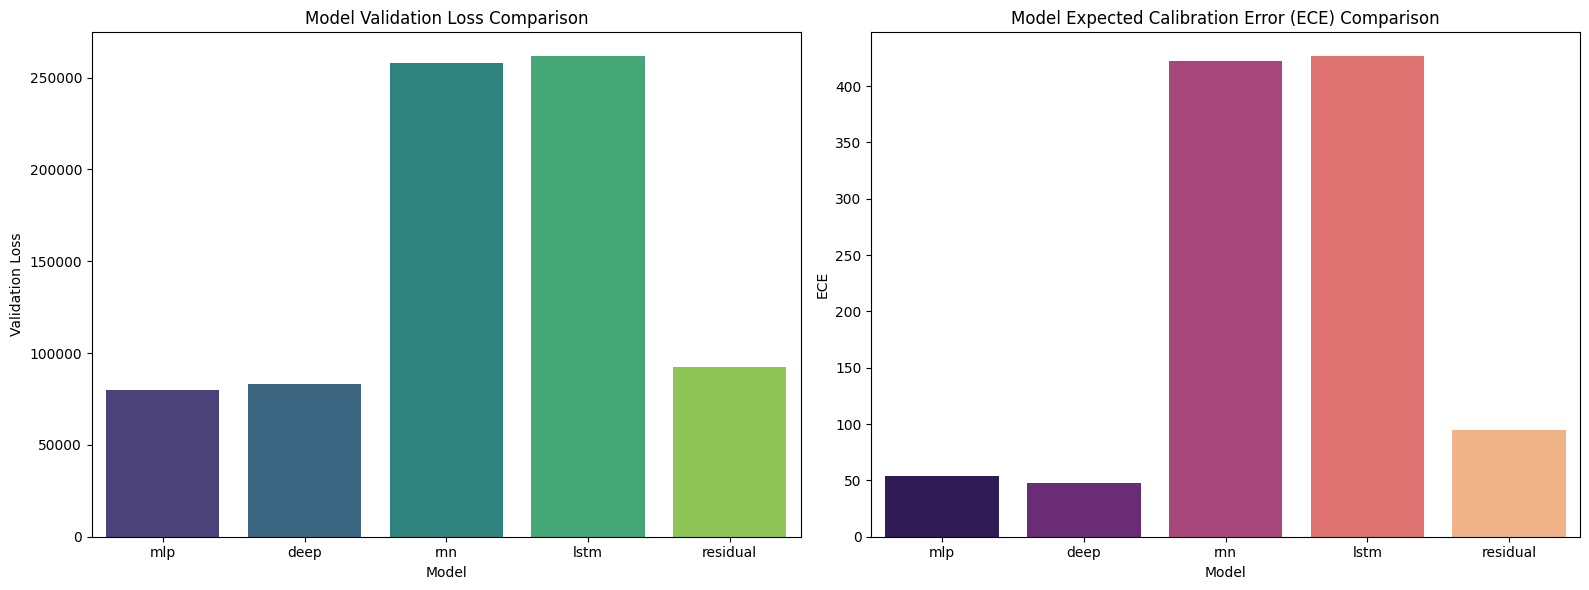

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create two subplots for val_loss and ECE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Validation Loss
sns.barplot(x=comparison_df.index, y='val_loss', data=comparison_df, ax=axes[0], palette='viridis', hue=comparison_df.index, legend=False)
axes[0].set_title('Model Validation Loss Comparison')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Validation Loss')
axes[0].ticklabel_format(style='plain', axis='y') # Prevent scientific notation for y-axis

# Plot ECE
sns.barplot(x=comparison_df.index, y='ECE', data=comparison_df, ax=axes[1], palette='magma', hue=comparison_df.index, legend=False)
axes[1].set_title('Model Expected Calibration Error (ECE) Comparison')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('ECE')

plt.tight_layout()

# Save the figure
plt.savefig('model_performance_comparison.png')
print("Performance comparison plot saved to 'model_performance_comparison.png'")
plt.show()

In [ ]:
print('Performance Comparison between MLP and Deep models:')
display(comparison_df.loc[['mlp', 'deep']])

mlp_val_loss = comparison_df.loc['mlp', 'val_loss']
deep_val_loss = comparison_df.loc['deep', 'val_loss']

mlp_ece = comparison_df.loc['mlp', 'ECE']
deep_ece = comparison_df.loc['deep', 'ECE']

if mlp_val_loss < deep_val_loss:
    print(f"\nMLP has a lower validation loss ({mlp_val_loss:.2f}) than Deep ({deep_val_loss:.2f}), indicating better accuracy.")
elif deep_val_loss < mlp_val_loss:
    print(f"\nDeep has a lower validation loss ({deep_val_loss:.2f}) than MLP ({mlp_val_loss:.2f}), indicating better accuracy.")
else:
    print(f"\nBoth MLP and Deep models have similar validation loss ({mlp_val_loss:.2f}).")

if mlp_ece < deep_ece:
    print(f"MLP has a lower ECE ({mlp_ece:.2f}) than Deep ({deep_ece:.2f}), suggesting better calibration.")
elif deep_ece < mlp_ece:
    print(f"Deep has a lower ECE ({deep_ece:.2f}) than MLP ({mlp_ece:.2f}), suggesting better calibration.")
else:
    print(f"Both MLP and Deep models have similar ECE ({mlp_ece:.2f}).")

Performance Comparison between MLP and Deep models:


,val_loss,ECE
Model,,
mlp,79900.796875,53.601337
deep,83424.023438,47.989731



MLP has a lower validation loss (79900.80) than Deep (83424.02), indicating better accuracy.
Deep has a lower ECE (47.99) than MLP (53.60), suggesting better calibration.


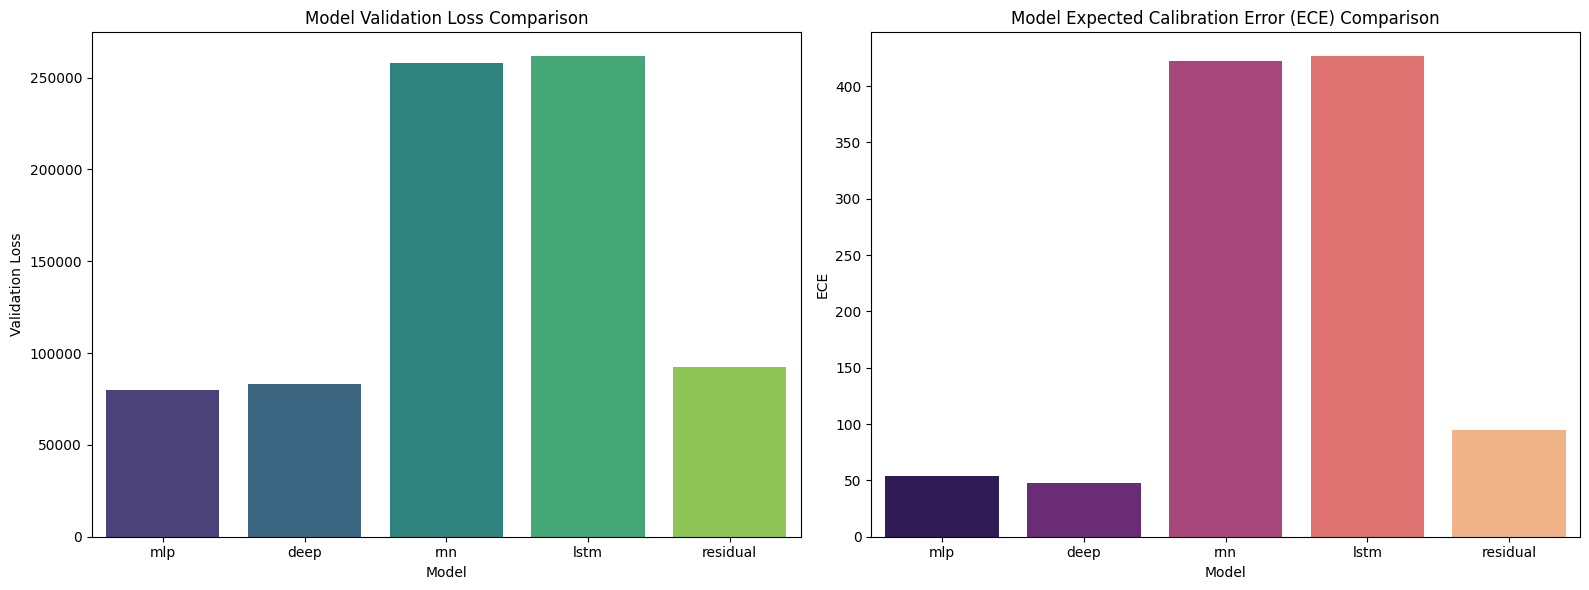

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create two subplots for val_loss and ECE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Validation Loss
sns.barplot(x=comparison_df.index, y='val_loss', data=comparison_df, ax=axes[0], palette='viridis', hue=comparison_df.index, legend=False)
axes[0].set_title('Model Validation Loss Comparison')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Validation Loss')
axes[0].ticklabel_format(style='plain', axis='y') # Prevent scientific notation for y-axis

# Plot ECE
sns.barplot(x=comparison_df.index, y='ECE', data=comparison_df, ax=axes[1], palette='magma', hue=comparison_df.index, legend=False)
axes[1].set_title('Model Expected Calibration Error (ECE) Comparison')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('ECE')

plt.tight_layout()
plt.show()

In [ ]:
display(comparison_df.describe())

,val_loss,ECE
count,5.000000,5.000000
mean,155068.718750,208.989304
std,95767.257812,197.480148
min,79900.796875,47.989731
25%,83424.023438,53.601337
50%,92316.953125,94.524101
75%,258133.890625,422.416687
max,261567.921875,426.414734


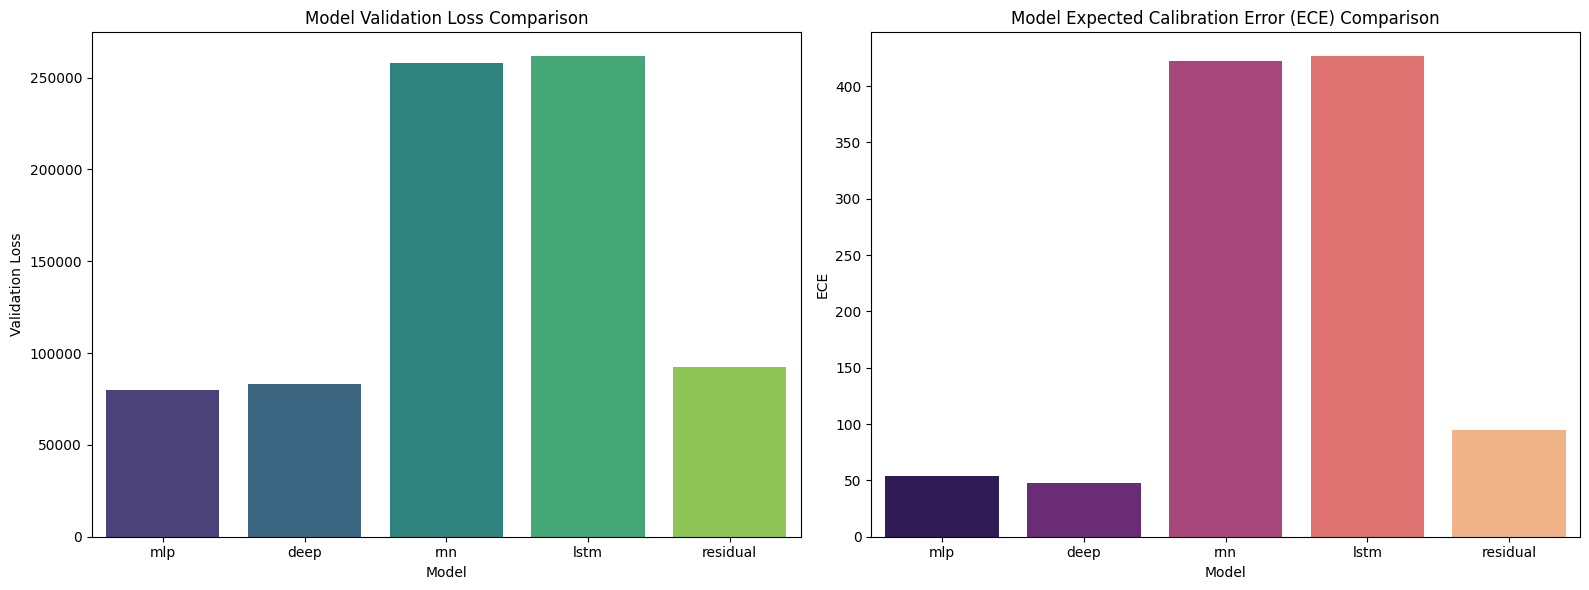

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create two subplots for val_loss and ECE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Validation Loss
sns.barplot(x=comparison_df.index, y='val_loss', data=comparison_df, ax=axes[0], palette='viridis', hue=comparison_df.index, legend=False)
axes[0].set_title('Model Validation Loss Comparison')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Validation Loss')
axes[0].ticklabel_format(style='plain', axis='y') # Prevent scientific notation for y-axis

# Plot ECE
sns.barplot(x=comparison_df.index, y='ECE', data=comparison_df, ax=axes[1], palette='magma', hue=comparison_df.index, legend=False)
axes[1].set_title('Model Expected Calibration Error (ECE) Comparison')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('ECE')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

model_names = ['mlp', 'deep', 'rnn', 'lstm', 'residual']
results_data = {}

for model in model_names:
    try:
        file_path = f'results/{model}_results.npz'
        with np.load(file_path, allow_pickle=True) as data:
            results_data[model] = {
                'val_loss': data['val_loss'][-1] if 'val_loss' in data else 'N/A',
                'ECE': data['ece_over_time'][-1] if 'ece_over_time' in data else 'N/A'
            }
    except FileNotFoundError:
        print(f"Warning: Results file for {model} not found.")
        results_data[model] = {'val_loss': 'File Not Found', 'ECE': 'File Not Found'}
    except Exception as e:
        print(f"Error loading results for {model}: {e}")
        results_data[model] = {'val_loss': 'Error', 'ECE': 'Error'}

comparison_df = pd.DataFrame.from_dict(results_data, orient='index')
comparison_df.index.name = 'Model'
print('Preliminary Model Comparison Table:')
print(comparison_df)

Preliminary Model Comparison Table:
               val_loss         ECE
Model                              
mlp        79900.796875   53.601337
deep       83424.023438   47.989731
rnn       258133.890625  422.416687
lstm      261567.921875  426.414734
residual   92316.953125   94.524101


In [ ]:
import numpy as np
import pandas as pd

model_names = ['mlp', 'deep', 'rnn', 'lstm', 'residual']
results_data = {}

for model in model_names:
    try:
        file_path = f'results/{model}_results.npz'
        with np.load(file_path, allow_pickle=True) as data:
            results_data[model] = {
                'val_loss': data['val_loss'][-1] if 'val_loss' in data else 'N/A',
                'ECE': data['ece_over_time'][-1] if 'ece_over_time' in data else 'N/A'
            }
    except FileNotFoundError:
        print(f"Warning: Results file for {model} not found.")
        results_data[model] = {'val_loss': 'File Not Found', 'ECE': 'File Not Found'}
    except Exception as e:
        print(f"Error loading results for {model}: {e}")
        results_data[model] = {'val_loss': 'Error', 'ECE': 'Error'}

comparison_df = pd.DataFrame.from_dict(results_data, orient='index')
comparison_df.index.name = 'Model'
print('Preliminary Model Comparison Table:')
print(comparison_df)

Preliminary Model Comparison Table:
               val_loss         ECE
Model                              
mlp        79900.796875   53.601337
deep       83424.023438   47.989731
rnn       258133.890625  422.416687
lstm      261567.921875  426.414734
residual   92316.953125   94.524101


In [ ]:
import numpy as np
import pandas as pd

model_names = ['mlp', 'deep', 'rnn', 'lstm', 'residual']
results_data = {}

for model in model_names:
    try:
        file_path = f'results/{model}_results.npz'
        with np.load(file_path, allow_pickle=True) as data:
            results_data[model] = {
                'val_loss': data['val_loss'][-1] if 'val_loss' in data else 'N/A',
                'ECE': data['ece_over_time'][-1] if 'ece_over_time' in data else 'N/A'
            }
    except FileNotFoundError:
        print(f"Warning: Results file for {model} not found.")
        results_data[model] = {'val_loss': 'File Not Found', 'ECE': 'File Not Found'}
    except Exception as e:
        print(f"Error loading results for {model}: {e}")
        results_data[model] = {'val_loss': 'Error', 'ECE': 'Error'}

comparison_df = pd.DataFrame.from_dict(results_data, orient='index')
comparison_df.index.name = 'Model'
print('Preliminary Model Comparison Table:')
print(comparison_df)

Preliminary Model Comparison Table:
               val_loss         ECE
Model                              
mlp        79900.796875   53.601337
deep       83424.023438   47.989731
rnn       258133.890625  422.416687
lstm      261567.921875  426.414734
residual   92316.953125   94.524101


In [ ]:
import numpy as np
import pandas as pd

model_names = ['mlp', 'deep', 'rnn', 'lstm', 'residual']
results_data = {}

for model in model_names:
    try:
        file_path = f'results/{model}_results.npz'
        with np.load(file_path, allow_pickle=True) as data:
            results_data[model] = {
                'val_loss': data['val_loss'][-1] if 'val_loss' in data else 'N/A',
                'ECE': data['ece_over_time'][-1] if 'ece_over_time' in data else 'N/A'
            }
    except FileNotFoundError:
        print(f"Warning: Results file for {model} not found.")
        results_data[model] = {'val_loss': 'File Not Found', 'ECE': 'File Not Found'}
    except Exception as e:
        print(f"Error loading results for {model}: {e}")
        results_data[model] = {'val_loss': 'Error', 'ECE': 'Error'}

comparison_df = pd.DataFrame.from_dict(results_data, orient='index')
comparison_df.index.name = 'Model'
print('Preliminary Model Comparison Table:')
print(comparison_df)

Preliminary Model Comparison Table:
               val_loss         ECE
Model                              
mlp        79900.796875   53.601337
deep       83424.023438   47.989731
rnn       258133.890625  422.416687
lstm      261567.921875  426.414734
residual   92316.953125   94.524101


In [ ]:
import numpy as np
import pandas as pd

model_names = ['mlp', 'deep', 'rnn', 'lstm', 'residual']
results_data = {}

for model in model_names:
    try:
        file_path = f'results/{model}_results.npz'
        with np.load(file_path, allow_pickle=True) as data:
            results_data[model] = {
                'val_loss': data['val_loss'][-1] if 'val_loss' in data else 'N/A',
                'ECE': data['ece_over_time'][-1] if 'ece_over_time' in data else 'N/A'
            }
    except FileNotFoundError:
        print(f"Warning: Results file for {model} not found.")
        results_data[model] = {'val_loss': 'File Not Found', 'ECE': 'File Not Found'}
    except Exception as e:
        print(f"Error loading results for {model}: {e}")
        results_data[model] = {'val_loss': 'Error', 'ECE': 'Error'}

comparison_df = pd.DataFrame.from_dict(results_data, orient='index')
comparison_df.index.name = 'Model'
print('Preliminary Model Comparison Table:')
print(comparison_df)

Preliminary Model Comparison Table:
               val_loss         ECE
Model                              
mlp        79900.796875   53.601337
deep       83424.023438   47.989731
rnn       258133.890625  422.416687
lstm      261567.921875  426.414734
residual   92316.953125   94.524101


In [ ]:
import numpy as np
import pandas as pd

model_names = ['mlp', 'deep', 'rnn', 'lstm', 'residual']
results_data = {}

for model in model_names:
    try:
        file_path = f'results/{model}_results.npz'
        with np.load(file_path, allow_pickle=True) as data:
            results_data[model] = {
                'val_loss': data['val_loss'][-1] if 'val_loss' in data else 'N/A',
                'ECE': data['ece_over_time'][-1] if 'ece_over_time' in data else 'N/A'
            }
    except FileNotFoundError:
        print(f"Warning: Results file for {model} not found.")
        results_data[model] = {'val_loss': 'File Not Found', 'ECE': 'File Not Found'}
    except Exception as e:
        print(f"Error loading results for {model}: {e}")
        results_data[model] = {'val_loss': 'Error', 'ECE': 'Error'}

comparison_df = pd.DataFrame.from_dict(results_data, orient='index')
comparison_df.index.name = 'Model'
print('Preliminary Model Comparison Table:')
print(comparison_df)

Preliminary Model Comparison Table:
               val_loss         ECE
Model                              
mlp        79900.796875   53.601337
deep       83424.023438   47.989731
rnn       258133.890625  422.416687
lstm      261567.921875  426.414734
residual   92316.953125   94.524101


In [ ]:
import numpy as np
import pandas as pd

model_names = ['mlp', 'deep', 'rnn', 'lstm', 'residual']
results_data = {}

for model in model_names:
    try:
        file_path = f'results/{model}_results.npz'
        with np.load(file_path, allow_pickle=True) as data:
            results_data[model] = {
                'val_loss': data['val_loss'][-1] if 'val_loss' in data else 'N/A',
                'ECE': data['ece_over_time'][-1] if 'ece_over_time' in data else 'N/A'
            }
    except FileNotFoundError:
        print(f"Warning: Results file for {model} not found.")
        results_data[model] = {'val_loss': 'File Not Found', 'ECE': 'File Not Found'}
    except Exception as e:
        print(f"Error loading results for {model}: {e}")
        results_data[model] = {'val_loss': 'Error', 'ECE': 'Error'}

comparison_df = pd.DataFrame.from_dict(results_data, orient='index')
comparison_df.index.name = 'Model'
print('Preliminary Model Comparison Table:')
print(comparison_df)

Preliminary Model Comparison Table:
               val_loss         ECE
Model                              
mlp        79900.796875   53.601337
deep       83424.023438   47.989731
rnn       258133.890625  422.416687
lstm      261567.921875  426.414734
residual   92316.953125   94.524101


In [ ]:
import numpy as np
import pandas as pd

model_names = ['mlp', 'deep', 'rnn', 'lstm', 'residual']
results_data = {}

for model in model_names:
    try:
        file_path = f'results/{model}_results.npz'
        with np.load(file_path, allow_pickle=True) as data:
            results_data[model] = {
                'val_loss': data['val_loss'][-1] if 'val_loss' in data else 'N/A',
                'ECE': data['ece_over_time'][-1] if 'ece_over_time' in data else 'N/A'
            }
    except FileNotFoundError:
        print(f"Warning: Results file for {model} not found.")
        results_data[model] = {'val_loss': 'File Not Found', 'ECE': 'File Not Found'}
    except Exception as e:
        print(f"Error loading results for {model}: {e}")
        results_data[model] = {'val_loss': 'Error', 'ECE': 'Error'}

comparison_df = pd.DataFrame.from_dict(results_data, orient='index')
comparison_df.index.name = 'Model'
print('Preliminary Model Comparison Table:')
print(comparison_df)

Preliminary Model Comparison Table:
               val_loss         ECE
Model                              
mlp        79900.796875   53.601337
deep       83424.023438   47.989731
rnn       258133.890625  422.416687
lstm      261567.921875  426.414734
residual   92316.953125   94.524101


In [ ]:
import numpy as np
import pandas as pd

model_names = ['mlp', 'deep', 'rnn', 'lstm', 'residual']
results_data = {}

for model in model_names:
    try:
        file_path = f'results/{model}_results.npz'
        with np.load(file_path, allow_pickle=True) as data:
            results_data[model] = {
                'val_loss': data['val_loss'][-1] if 'val_loss' in data else 'N/A',
                'ECE': data['ece_over_time'][-1] if 'ece_over_time' in data else 'N/A'
            }
    except FileNotFoundError:
        print(f"Warning: Results file for {model} not found.")
        results_data[model] = {'val_loss': 'File Not Found', 'ECE': 'File Not Found'}
    except Exception as e:
        print(f"Error loading results for {model}: {e}")
        results_data[model] = {'val_loss': 'Error', 'ECE': 'Error'}

comparison_df = pd.DataFrame.from_dict(results_data, orient='index')
comparison_df.index.name = 'Model'
print('Preliminary Model Comparison Table:')
print(comparison_df)

Preliminary Model Comparison Table:
               val_loss         ECE
Model                              
mlp        79900.796875   53.601337
deep       83424.023438   47.989731
rnn       258133.890625  422.416687
lstm      261567.921875  426.414734
residual   92316.953125   94.524101


In [ ]:
import numpy as np
import pandas as pd

model_names = ['mlp', 'deep', 'rnn', 'lstm', 'residual']
results_data = {}

for model in model_names:
    try:
        file_path = f'results/{model}_results.npz'
        with np.load(file_path, allow_pickle=True) as data:
            results_data[model] = {
                'val_loss': data['val_loss'][-1] if 'val_loss' in data else 'N/A',
                'ECE': data['ece_over_time'][-1] if 'ece_over_time' in data else 'N/A'
            }
    except FileNotFoundError:
        print(f"Warning: Results file for {model} not found.")
        results_data[model] = {'val_loss': 'File Not Found', 'ECE': 'File Not Found'}
    except Exception as e:
        print(f"Error loading results for {model}: {e}")
        results_data[model] = {'val_loss': 'Error', 'ECE': 'Error'}

comparison_df = pd.DataFrame.from_dict(results_data, orient='index')
comparison_df.index.name = 'Model'
print('Preliminary Model Comparison Table:')
print(comparison_df)

Preliminary Model Comparison Table:
               val_loss         ECE
Model                              
mlp        79900.796875   53.601337
deep       83424.023438   47.989731
rnn       258133.890625  422.416687
lstm      261567.921875  426.414734
residual   92316.953125   94.524101


In [ ]:
%%bash
python experiments/inspect_results.py --help

Available keys: ['predictions', 'targets', 'per_example_loss', 'epochs', 'train_loss', 'val_loss', 'ece_over_time', 'train_grad_norm']
Predictions shape: (456, 1)
Targets shape: (456, 1)
Per-example loss shape: (456,), mean: 78163.2891


In [ ]:
%%bash
python experiments/inspect_results.py --help

Available keys: ['predictions', 'targets', 'per_example_loss', 'epochs', 'train_loss', 'val_loss', 'ece_over_time', 'train_grad_norm']
Predictions shape: (456, 1)
Targets shape: (456, 1)
Per-example loss shape: (456,), mean: 78163.2891


In [ ]:
%%bash
python experiments/inspect_results.py --help

Available keys: ['predictions', 'targets', 'per_example_loss', 'epochs', 'train_loss', 'val_loss', 'ece_over_time', 'train_grad_norm']
Predictions shape: (456, 1)
Targets shape: (456, 1)
Per-example loss shape: (456,), mean: 78163.2891


In [ ]:
%%bash
python experiments/inspect_results.py --help

Available keys: ['predictions', 'targets', 'per_example_loss', 'epochs', 'train_loss', 'val_loss', 'ece_over_time', 'train_grad_norm']
Predictions shape: (456, 1)
Targets shape: (456, 1)
Per-example loss shape: (456,), mean: 78163.2891


In [ ]:
%%bash
python experiments/inspect_results.py --help

Available keys: ['predictions', 'targets', 'per_example_loss', 'epochs', 'train_loss', 'val_loss', 'ece_over_time', 'train_grad_norm']
Predictions shape: (456, 1)
Targets shape: (456, 1)
Per-example loss shape: (456,), mean: 78163.2891


In [ ]:
%%bash
python experiments/inspect_results.py --help

Available keys: ['predictions', 'targets', 'per_example_loss', 'epochs', 'train_loss', 'val_loss', 'ece_over_time', 'train_grad_norm']
Predictions shape: (456, 1)
Targets shape: (456, 1)
Per-example loss shape: (456,), mean: 78163.2891


In [ ]:
%%bash
python experiments/inspect_results.py --help

Available keys: ['predictions', 'targets', 'per_example_loss', 'epochs', 'train_loss', 'val_loss', 'ece_over_time', 'train_grad_norm']
Predictions shape: (456, 1)
Targets shape: (456, 1)
Per-example loss shape: (456,), mean: 78163.2891


In [ ]:
%%bash
python experiments/inspect_results.py --help

Available keys: ['predictions', 'targets', 'per_example_loss', 'epochs', 'train_loss', 'val_loss', 'ece_over_time', 'train_grad_norm']
Predictions shape: (456, 1)
Targets shape: (456, 1)
Per-example loss shape: (456,), mean: 78163.2891


In [ ]:
%%bash
python experiments/inspect_results.py --help

Available keys: ['predictions', 'targets', 'per_example_loss', 'epochs', 'train_loss', 'val_loss', 'ece_over_time', 'train_grad_norm']
Predictions shape: (456, 1)
Targets shape: (456, 1)
Per-example loss shape: (456,), mean: 78163.2891


In [ ]:
%%bash
python experiments/inspect_results.py --help

Available keys: ['predictions', 'targets', 'per_example_loss', 'epochs', 'train_loss', 'val_loss', 'ece_over_time', 'train_grad_norm']
Predictions shape: (456, 1)
Targets shape: (456, 1)
Per-example loss shape: (456,), mean: 78163.2891


In [ ]:
%%bash
python experiments/train.py --model mlp --data-path data/finsen/raw --results-path results/mlp_results.npz

Using device: cuda
Found 3 CSV files: ['FinSen_US_Categorized_Timestamp.csv', 'FinSen_US_Categorized.csv', 'FinSen_US.csv']
Loaded FinSen_US_Categorized_Timestamp.csv: 15534 rows, 4 columns
Loaded FinSen_US_Categorized.csv: 15534 rows, 4 columns
Loaded FinSen_US.csv: 15534 rows, 3 columns
Merged data: 15534 rows, 4 columns
No numeric columns found in raw CSVs; trying processed folder: data/finsen/processed
Found 3 CSV files: ['train.csv', 'val.csv', 'test.csv']
Loaded train.csv: 10873 rows, 5 columns
Loaded val.csv: 2330 rows, 5 columns
Loaded test.csv: 2331 rows, 5 columns
Dropped non-numeric columns: ['Category', 'Content', 'Tag', 'Title']
Loading checkpoint from results/checkpoints/model.pt
Checkpoint is for model 'residual', current is 'mlp'; starting fresh.
Epoch   1 | train_loss=98218.001304 | val_loss=78282.480938 | ECE=43.2058 | acc=0.001
Saved new best checkpoint to results/checkpoints/model.pt
Epoch   2 | train_loss=80738.390422 | val_loss=77492.074688 | ECE=35.6195 | acc=0.0

2026-03-19 16:53:05.799195: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773939185.819564   16170 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773939185.826275   16170 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773939185.843394   16170 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773939185.843438   16170 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773939185.843442   16170 computation_placer.cc:177] computation placer alr

In [ ]:
%%bash
python experiments/train.py --model deep --data-path data/finsen/raw --results-path results/deep_results.npz

Using device: cuda
Found 3 CSV files: ['FinSen_US_Categorized_Timestamp.csv', 'FinSen_US_Categorized.csv', 'FinSen_US.csv']
Loaded FinSen_US_Categorized_Timestamp.csv: 15534 rows, 4 columns
Loaded FinSen_US_Categorized.csv: 15534 rows, 4 columns
Loaded FinSen_US.csv: 15534 rows, 3 columns
Merged data: 15534 rows, 4 columns
No numeric columns found in raw CSVs; trying processed folder: data/finsen/processed
Found 3 CSV files: ['train.csv', 'val.csv', 'test.csv']
Loaded train.csv: 10873 rows, 5 columns
Loaded val.csv: 2330 rows, 5 columns
Loaded test.csv: 2331 rows, 5 columns
Dropped non-numeric columns: ['Category', 'Content', 'Tag', 'Title']
Loading checkpoint from results/checkpoints/model.pt
Checkpoint is for model 'mlp', current is 'deep'; starting fresh.
Epoch   1 | train_loss=113160.400104 | val_loss=81904.544391 | ECE=43.2249 | acc=0.002
Saved new best checkpoint to results/checkpoints/model.pt
Epoch   2 | train_loss=80315.082203 | val_loss=83167.153607 | ECE=51.9012 | acc=0.000


2026-03-19 16:53:24.331340: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773939204.354015   16259 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773939204.361464   16259 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773939204.381113   16259 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773939204.381153   16259 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773939204.381157   16259 computation_placer.cc:177] computation placer alr

In [ ]:
%%bash
python experiments/train.py --model rnn --data-path data/finsen/raw --results-path results/rnn_results.npz

Using device: cuda
Found 3 CSV files: ['FinSen_US_Categorized_Timestamp.csv', 'FinSen_US_Categorized.csv', 'FinSen_US.csv']
Loaded FinSen_US_Categorized_Timestamp.csv: 15534 rows, 4 columns
Loaded FinSen_US_Categorized.csv: 15534 rows, 4 columns
Loaded FinSen_US.csv: 15534 rows, 3 columns
Merged data: 15534 rows, 4 columns
No numeric columns found in raw CSVs; trying processed folder: data/finsen/processed
Found 3 CSV files: ['train.csv', 'val.csv', 'test.csv']
Loaded train.csv: 10873 rows, 5 columns
Loaded val.csv: 2330 rows, 5 columns
Loaded test.csv: 2331 rows, 5 columns
Dropped non-numeric columns: ['Category', 'Content', 'Tag', 'Title']
Loading checkpoint from results/checkpoints/model.pt
Checkpoint is for model 'deep', current is 'rnn'; starting fresh.
Epoch   1 | train_loss=329567.903792 | val_loss=332835.810767 | ECE=503.1280 | acc=0.000
Saved new best checkpoint to results/checkpoints/model.pt
Epoch   2 | train_loss=324770.773783 | val_loss=328362.029171 | ECE=498.6622 | acc=0

2026-03-19 16:53:42.060698: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773939222.082580   16348 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773939222.089740   16348 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773939222.108049   16348 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773939222.108096   16348 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773939222.108100   16348 computation_placer.cc:177] computation placer alr

In [ ]:
%%bash
python experiments/train.py --model lstm --data-path data/finsen/raw --results-path results/lstm_results.npz

Using device: cuda
Found 3 CSV files: ['FinSen_US_Categorized_Timestamp.csv', 'FinSen_US_Categorized.csv', 'FinSen_US.csv']
Loaded FinSen_US_Categorized_Timestamp.csv: 15534 rows, 4 columns
Loaded FinSen_US_Categorized.csv: 15534 rows, 4 columns
Loaded FinSen_US.csv: 15534 rows, 3 columns
Merged data: 15534 rows, 4 columns
No numeric columns found in raw CSVs; trying processed folder: data/finsen/processed
Found 3 CSV files: ['train.csv', 'val.csv', 'test.csv']
Loaded train.csv: 10873 rows, 5 columns
Loaded val.csv: 2330 rows, 5 columns
Loaded test.csv: 2331 rows, 5 columns
Dropped non-numeric columns: ['Category', 'Content', 'Tag', 'Title']
Loading checkpoint from results/checkpoints/model.pt
Checkpoint is for model 'rnn', current is 'lstm'; starting fresh.
Epoch   1 | train_loss=331894.170397 | val_loss=332133.468750 | ECE=502.3896 | acc=0.000
Saved new best checkpoint to results/checkpoints/model.pt
Epoch   2 | train_loss=326561.662678 | val_loss=326034.990816 | ECE=496.2831 | acc=0

2026-03-19 16:54:04.405306: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773939244.426226   16453 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773939244.433450   16453 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773939244.451667   16453 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773939244.451715   16453 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773939244.451719   16453 computation_placer.cc:177] computation placer alr

In [ ]:
%%bash
python experiments/train.py --model residual --data-path data/finsen/raw --results-path results/residual_results.npz

Using device: cuda
Found 3 CSV files: ['FinSen_US_Categorized_Timestamp.csv', 'FinSen_US_Categorized.csv', 'FinSen_US.csv']
Loaded FinSen_US_Categorized_Timestamp.csv: 15534 rows, 4 columns
Loaded FinSen_US_Categorized.csv: 15534 rows, 4 columns
Loaded FinSen_US.csv: 15534 rows, 3 columns
Merged data: 15534 rows, 4 columns
No numeric columns found in raw CSVs; trying processed folder: data/finsen/processed
Found 3 CSV files: ['train.csv', 'val.csv', 'test.csv']
Loaded train.csv: 10873 rows, 5 columns
Loaded val.csv: 2330 rows, 5 columns
Loaded test.csv: 2331 rows, 5 columns
Dropped non-numeric columns: ['Category', 'Content', 'Tag', 'Title']
Loading checkpoint from results/checkpoints/model.pt
Checkpoint is for model 'lstm', current is 'residual'; starting fresh.
Epoch   1 | train_loss=90941.349411 | val_loss=80073.524665 | ECE=40.4666 | acc=0.001
Saved new best checkpoint to results/checkpoints/model.pt
Epoch   2 | train_loss=80439.963463 | val_loss=83486.939421 | ECE=64.7015 | acc=0.

2026-03-19 16:54:26.121901: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773939266.159232   16557 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773939266.170776   16557 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773939266.197766   16557 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773939266.197835   16557 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773939266.197849   16557 computation_placer.cc:177] computation placer alr

In [ ]:
import os
os.listdir('data')

['preprocessing', 'finsen']

In [ ]:
import os
os.listdir('data')

['preprocessing', 'finsen']

In [ ]:
import os
os.listdir('data')

['preprocessing', 'finsen']

In [ ]:
os.listdir('data')

['preprocessing', 'finsen']

In [ ]:
%%bash
python experiments/train.py --model mlp --data-path data/finsen/raw --results-path results/mlp_results.npz

Using device: cuda
Found 3 CSV files: ['FinSen_US_Categorized_Timestamp.csv', 'FinSen_US_Categorized.csv', 'FinSen_US.csv']
Loaded FinSen_US_Categorized_Timestamp.csv: 15534 rows, 4 columns
Loaded FinSen_US_Categorized.csv: 15534 rows, 4 columns
Loaded FinSen_US.csv: 15534 rows, 3 columns
Merged data: 15534 rows, 4 columns
No numeric columns found in raw CSVs; trying processed folder: data/finsen/processed
Found 3 CSV files: ['train.csv', 'val.csv', 'test.csv']
Loaded train.csv: 10873 rows, 5 columns
Loaded val.csv: 2330 rows, 5 columns
Loaded test.csv: 2331 rows, 5 columns
Dropped non-numeric columns: ['Category', 'Content', 'Tag', 'Title']
Loading checkpoint from results/checkpoints/model.pt
Resuming from epoch 14 (best_val_loss=71405.344435)
Epoch  14 | train_loss=80639.847501 | val_loss=81607.054688 | ECE=55.9638 | acc=0.000
Epoch  15 | train_loss=79519.973434 | val_loss=80741.759574 | ECE=46.7245 | acc=0.001
Epoch  16 | train_loss=79453.453027 | val_loss=81413.162358 | ECE=48.8930

2026-03-19 16:51:25.013850: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773939085.035582   15667 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773939085.042856   15667 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773939085.061723   15667 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773939085.061762   15667 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773939085.061765   15667 computation_placer.cc:177] computation placer alr

In [ ]:
%%bash
python experiments/train.py --model deep --data-path data/finsen/raw --results-path results/deep_results.npz

Using device: cuda
Found 3 CSV files: ['FinSen_US_Categorized_Timestamp.csv', 'FinSen_US_Categorized.csv', 'FinSen_US.csv']
Loaded FinSen_US_Categorized_Timestamp.csv: 15534 rows, 4 columns
Loaded FinSen_US_Categorized.csv: 15534 rows, 4 columns
Loaded FinSen_US.csv: 15534 rows, 3 columns
Merged data: 15534 rows, 4 columns
No numeric columns found in raw CSVs; trying processed folder: data/finsen/processed
Found 3 CSV files: ['train.csv', 'val.csv', 'test.csv']
Loaded train.csv: 10873 rows, 5 columns
Loaded val.csv: 2330 rows, 5 columns
Loaded test.csv: 2331 rows, 5 columns
Dropped non-numeric columns: ['Category', 'Content', 'Tag', 'Title']
Loading checkpoint from results/checkpoints/model.pt
Checkpoint is for model 'mlp', current is 'deep'; starting fresh.
Epoch   1 | train_loss=108164.946263 | val_loss=78391.174763 | ECE=31.8143 | acc=0.000
Saved new best checkpoint to results/checkpoints/model.pt
Epoch   2 | train_loss=80764.559721 | val_loss=80789.764643 | ECE=52.3658 | acc=0.001


2026-03-19 16:51:45.426923: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773939105.447805   15770 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773939105.454609   15770 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773939105.472073   15770 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773939105.472114   15770 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773939105.472117   15770 computation_placer.cc:177] computation placer alr

In [ ]:
%%bash
python experiments/train.py --model rnn --data-path data/finsen/raw --results-path results/rnn_results.npz

Using device: cuda
Found 3 CSV files: ['FinSen_US_Categorized_Timestamp.csv', 'FinSen_US_Categorized.csv', 'FinSen_US.csv']
Loaded FinSen_US_Categorized_Timestamp.csv: 15534 rows, 4 columns
Loaded FinSen_US_Categorized.csv: 15534 rows, 4 columns
Loaded FinSen_US.csv: 15534 rows, 3 columns
Merged data: 15534 rows, 4 columns
No numeric columns found in raw CSVs; trying processed folder: data/finsen/processed
Found 3 CSV files: ['train.csv', 'val.csv', 'test.csv']
Loaded train.csv: 10873 rows, 5 columns
Loaded val.csv: 2330 rows, 5 columns
Loaded test.csv: 2331 rows, 5 columns
Dropped non-numeric columns: ['Category', 'Content', 'Tag', 'Title']
Loading checkpoint from results/checkpoints/model.pt
Checkpoint is for model 'deep', current is 'rnn'; starting fresh.
Epoch   1 | train_loss=329713.405936 | val_loss=333465.091728 | ECE=505.1044 | acc=0.000
Saved new best checkpoint to results/checkpoints/model.pt
Epoch   2 | train_loss=324688.508441 | val_loss=329035.018195 | ECE=500.6999 | acc=0

2026-03-19 16:52:03.082163: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773939123.103162   15859 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773939123.110241   15859 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773939123.128073   15859 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773939123.128118   15859 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773939123.128122   15859 computation_placer.cc:177] computation placer alr

In [ ]:
%%bash
python experiments/train.py --model lstm --data-path data/finsen/raw --results-path results/lstm_results.npz

Using device: cuda
Found 3 CSV files: ['FinSen_US_Categorized_Timestamp.csv', 'FinSen_US_Categorized.csv', 'FinSen_US.csv']
Loaded FinSen_US_Categorized_Timestamp.csv: 15534 rows, 4 columns
Loaded FinSen_US_Categorized.csv: 15534 rows, 4 columns
Loaded FinSen_US.csv: 15534 rows, 3 columns
Merged data: 15534 rows, 4 columns
No numeric columns found in raw CSVs; trying processed folder: data/finsen/processed
Found 3 CSV files: ['train.csv', 'val.csv', 'test.csv']
Loaded train.csv: 10873 rows, 5 columns
Loaded val.csv: 2330 rows, 5 columns
Loaded test.csv: 2331 rows, 5 columns
Dropped non-numeric columns: ['Category', 'Content', 'Tag', 'Title']
Loading checkpoint from results/checkpoints/model.pt
Checkpoint is for model 'rnn', current is 'lstm'; starting fresh.
Epoch   1 | train_loss=332195.939470 | val_loss=328615.806550 | ECE=500.8221 | acc=0.000
Saved new best checkpoint to results/checkpoints/model.pt
Epoch   2 | train_loss=325149.777977 | val_loss=321531.966671 | ECE=493.6991 | acc=0

2026-03-19 16:52:24.592722: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773939144.613263   15957 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773939144.620083   15957 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773939144.637250   15957 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773939144.637292   15957 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773939144.637296   15957 computation_placer.cc:177] computation placer alr

In [ ]:
%%bash
python experiments/train.py --model residual --data-path data/finsen/raw --results-path results/residual_results.npz

Using device: cuda
Found 3 CSV files: ['FinSen_US_Categorized_Timestamp.csv', 'FinSen_US_Categorized.csv', 'FinSen_US.csv']
Loaded FinSen_US_Categorized_Timestamp.csv: 15534 rows, 4 columns
Loaded FinSen_US_Categorized.csv: 15534 rows, 4 columns
Loaded FinSen_US.csv: 15534 rows, 3 columns
Merged data: 15534 rows, 4 columns
No numeric columns found in raw CSVs; trying processed folder: data/finsen/processed
Found 3 CSV files: ['train.csv', 'val.csv', 'test.csv']
Loaded train.csv: 10873 rows, 5 columns
Loaded val.csv: 2330 rows, 5 columns
Loaded test.csv: 2331 rows, 5 columns
Dropped non-numeric columns: ['Category', 'Content', 'Tag', 'Title']
Loading checkpoint from results/checkpoints/model.pt
Checkpoint is for model 'lstm', current is 'residual'; starting fresh.
Epoch   1 | train_loss=92313.595278 | val_loss=80559.018788 | ECE=38.3972 | acc=0.002
Saved new best checkpoint to results/checkpoints/model.pt
Epoch   2 | train_loss=80405.767281 | val_loss=80187.122170 | ECE=37.0836 | acc=0.

2026-03-19 16:52:46.024655: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773939166.059201   16067 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773939166.071458   16067 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773939166.100447   16067 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773939166.100524   16067 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773939166.100538   16067 computation_placer.cc:177] computation placer alr

In [ ]:
%%bash
python experiments/train.py --help

usage: train.py [-h] [--data-path DATA_PATH] [--seq-len SEQ_LEN]
                [--batch-size BATCH_SIZE] [--epochs EPOCHS] [--lr LR]
                [--val-ratio VAL_RATIO] [--model {mlp,deep,rnn,lstm,residual}]
                [--checkpoint-path CHECKPOINT_PATH] [--no-resume]
                [--early-stopping-patience EARLY_STOPPING_PATIENCE]
                [--log-backend {none,tensorboard,wandb}] [--log-dir LOG_DIR]
                [--wandb-project WANDB_PROJECT]
                [--wandb-run-name WANDB_RUN_NAME]
                [--results-path RESULTS_PATH]

Train a windowed model on FinSen data

options:
  -h, --help            show this help message and exit
  --data-path DATA_PATH
                        Path to FinSen raw CSV files
  --seq-len SEQ_LEN     Sequence length (window size)
  --batch-size BATCH_SIZE
                        Training batch size
  --epochs EPOCHS       Number of training epochs
  --lr LR               Learning rate
  --val-ratio VAL_RATIO
             

2026-03-19 16:48:04.701952: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773938884.726359   14707 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773938884.733570   14707 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773938884.752693   14707 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773938884.752733   14707 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773938884.752736   14707 computation_placer.cc:177] computation placer alr

In [ ]:
%%bash
python experiments/train.py --help

usage: train.py [-h] [--data-path DATA_PATH] [--seq-len SEQ_LEN]
                [--batch-size BATCH_SIZE] [--epochs EPOCHS] [--lr LR]
                [--val-ratio VAL_RATIO] [--model {mlp,deep,rnn,lstm,residual}]
                [--checkpoint-path CHECKPOINT_PATH] [--no-resume]
                [--early-stopping-patience EARLY_STOPPING_PATIENCE]
                [--log-backend {none,tensorboard,wandb}] [--log-dir LOG_DIR]
                [--wandb-project WANDB_PROJECT]
                [--wandb-run-name WANDB_RUN_NAME]
                [--results-path RESULTS_PATH]

Train a windowed model on FinSen data

options:
  -h, --help            show this help message and exit
  --data-path DATA_PATH
                        Path to FinSen raw CSV files
  --seq-len SEQ_LEN     Sequence length (window size)
  --batch-size BATCH_SIZE
                        Training batch size
  --epochs EPOCHS       Number of training epochs
  --lr LR               Learning rate
  --val-ratio VAL_RATIO
             

2026-03-19 16:48:19.217581: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773938899.238495   14792 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773938899.245334   14792 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773938899.263238   14792 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773938899.263273   14792 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773938899.263276   14792 computation_placer.cc:177] computation placer alr

In [ ]:
os.listdir('experiments')

['train.py',
 'inspect_results.py',
 'robustness_tests.py',
 'hyperparameter_tune.py',
 'plot_ece_over_time.py']

In [ ]:
os.listdir('experiments')

['train.py',
 'inspect_results.py',
 'robustness_tests.py',
 'hyperparameter_tune.py',
 'plot_ece_over_time.py']

In [ ]:
import os
os.chdir('Calibration-Confidence')

In [ ]:
os.listdir()

['loader_demo.py',
 'tmp_stats.py',
 'preprocessing',
 'data',
 'models',
 'notebooks',
 'setup.py',
 'path',
 'tests',
 'demo.py',
 'experiments',
 '.gitignore',
 'results',
 'README.md',
 '.git',
 'calibration',
 'requirements.txt']